# Influenza Forecasting — Perturbation Virtual Trajectories

**Method:** Fit the two-strain vaccination ODE model to observed data, then generate a
large synthetic dataset by randomly perturbing the fitted parameters around every
season's individual fitted baseline.

## Workflow
1. **Setup** — imports, file paths, and all configurable settings
2. **Data loading** — weekly influenza A/B hospitalization rates
3. **ODE model** — two-strain vaccination model (homogeneous & network)
4. **Fitting** — differential-evolution + least-squares global fit, one per real season
5. **Perturbation virtual dataset** — rejection-sampled synthetic trajectories
6. **CNN / LSTM evaluation** — forecasters trained and benchmarked on virtual data


## 0. Imports & Settings

In [40]:
# ============================================================
# 0. IMPORTS AND PROJECT SETTINGS
# ============================================================

from __future__ import annotations

from dataclasses import dataclass, asdict, replace
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import json
import os
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution, least_squares


# -----------------------------
# Folders
# -----------------------------
ROOT = Path("Subset")
ROOT.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Output file paths
# -----------------------------
VIRTUAL_OUTPUT_CSV           = ROOT / "virtual_dataset.csv"
VIRTUAL_BY_STRAIN_OUTPUT_CSV = ROOT / "virtual_patients_by_strain.csv"
VIRTUAL_STRAIN1_OUTPUT_CSV   = ROOT / "virtual_patients_influenza_A.csv"
VIRTUAL_STRAIN2_OUTPUT_CSV   = ROOT / "virtual_patients_influenza_B.csv"
VIRTUAL_OUTPUT_PNG           = ROOT / "virtual_examples.png"

SEASON_FITS_CSV              = ROOT / "season_fit_parameters.csv"

# -----------------------------
# Strain names
# -----------------------------
STRAIN1_NAME = "Influenza A"
STRAIN2_NAME = "Influenza B"

# ============================================================
# ODE MODEL SETTINGS
# ============================================================
MODEL_VERSION = "homogeneous"

DEGREES = np.arange(1, 11, dtype=float)
P_K = np.ones_like(DEGREES, dtype=float)
P_K = P_K / P_K.sum()

# ============================================================
# FITTING SETTINGS
# ============================================================
USE_WEIGHTED_FIT  = False
RANDOM_SEED       = 123
DE_MAXITER        = 100
DE_POPSIZE        = 5
DE_TOL            = 1e-4
DE_WORKERS        = max(1, (os.cpu_count() or 2))
LOCAL_MAX_NFEV    = 500
FIT_TO_TOTAL_ONLY = False   # each file is a single total-rate trajectory

FIXED_VALUES = {
    "r":      0.02,
    "mu":     0.0,
    "nu1":    0.0,
    "nu2":    0.0,
    "Lambda": 0.0,
    "V0":     0.0,
}

USE_TIME_VARYING_BETA         = False
BETA_MULTIPLIER_SMOOTH_WINDOW = 1
BETA_MULTIPLIER_GROWTH_GAIN   = 3.0
BETA_MULTIPLIER_MIN           = 0.05
BETA_MULTIPLIER_MAX           = 8.00

FIT_PARAMETER_NAMES = [
    "beta1", "beta2", "sigma",
    "gamma1", "gamma2",
    "r", "mu", "nu1", "nu2", "Lambda",
    "I10", "I20", "V0",
    "rho1", "rho2",
]

# Static list of all PaperParams fields (must match dataclass field order)
PAPER_PARAM_FIELD_NAMES = [
    "beta1", "beta2", "sigma", "gamma1", "gamma2",
    "r", "mu", "nu1", "nu2", "Lambda",
    "rho1", "rho2", "I10", "I20", "V0",
]

PARAMETER_BOUNDS = {
    "beta1":  (1e-4, 10.0),
    "beta2":  (1e-4, 10.0),
    "sigma":  (1e-8, 10.0),
    "I10":    (1e-10, 0.20),
    "I20":    (1e-10, 0.20),
    "rho1":   (1e-8,  1e8),
    "rho2":   (1e-8,  1e8),
    "gamma1": (0.2,   4.0),
    "gamma2": (0.2,   4.0),
    "r":      (1e-8,  1.0),
    "mu":     (1e-8,  0.05),
    "nu1":    (1e-8,  1.0),
    "nu2":    (1e-8,  1.0),
    "Lambda": (1e-8,  0.10),
    "V0":     (1e-10, 0.50),
}

# ============================================================
# PER-SEASON FITTING SETTINGS
# ============================================================
REFIT_SEASONS         = False
SEASON_LOCAL_MAX_NFEV = 1000
SEASON_DE_MAXITER     = 100
SEASON_DE_POPSIZE     = 10
SEASON_DE_TOL         = 1e-4
SEASON_DE_WORKERS     = DE_WORKERS

# ============================================================
# PERTURBATION / VIRTUAL-DATASET SETTINGS
# ============================================================
PERTURB_AMOUNT                            = 0.25
N_VIRTUAL_TRAJECTORIES_PER_SEASON         = 100
VIRTUAL_RANDOM_SEED                       = 123
N_EXAMPLE_VIRTUAL_PLOTS                   = 10
MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE = 0.20
REQUIRE_UNIQUE_SYNTHETIC_PERTURBATIONS    = True
PERTURBATION_SIGNATURE_DECIMALS           = 5
SYNTHETIC_TRAJECTORY_DISPLAY_FRACTION    = .1
SYNTHETIC_TRAJECTORIES_PER_DISPLAY_GRAPH = 10
SYNTHETIC_TRAJECTORY_DISPLAY_RANDOM_SEED = VIRTUAL_RANDOM_SEED
OBSERVED_BOUND_SLACK_FRACTION             = 0.0
MAX_VIRTUAL_GENERATION_ATTEMPTS           = 1000
OBSERVED_BOUND_TOLERANCE                  = 1e-12

PERTURB_PARAMETER_NAMES = [
    "beta1", "beta2",
    "sigma",
    "r",
    "gamma1", "gamma2",
    "I10",   "I20",
]

PERTURB_AMOUNT_BY_PARAM = {}  # all parameters use PERTURB_AMOUNT

# Disabled: with a single season min_observed == max_observed every week,
# so the slack formula (fraction * width) always produces zero slack and
# every perturbed trajectory is rejected.
ENFORCE_OBSERVED_MIN_MAX_BOUNDS = False


## 1. Load and summarize weekly rates by strain

In [41]:
# ============================================================
# 1B. LOAD DATASET TRAJECTORIES
# ============================================================

NETWORK_TARGETS = ("EIP", "FluSurv-NET", "IHSP")
NETWORK_COLORS = {
    "EIP":         "#1f77b4",
    "FluSurv-NET": "#ff7f0e",
    "IHSP":        "#2ca02c",
}

A_VIRUS_LABELS = {"Influenza A", "A H1N1 pdm09", "A H3N2"}
B_VIRUS_LABELS = {"Influenza B"}


def parse_dataset_filename(stem: str):
    for net in NETWORK_TARGETS:
        if stem.startswith(net + "_"):
            rest = stem[len(net) + 1:]
            m = re.match(r'^(\d{4}-\d{2})_(.+)$', rest)
            if m:
                return net, m.group(1), m.group(2).replace("_", " ")
    return None


# Load every CSV from Dataset/ that matches the naming convention
dataset_records = []
for csv_path in sorted(ROOT.glob("*.csv")):
    parsed = parse_dataset_filename(csv_path.stem)
    if parsed is None:
        continue
    network, season, virus = parsed
    try:
        df_traj = pd.read_csv(csv_path)
        df_traj.columns = [str(c).strip() for c in df_traj.columns]
        df_traj["week"]        = pd.to_numeric(df_traj["week"],        errors="coerce")
        df_traj["WEEKLY RATE"] = pd.to_numeric(df_traj["WEEKLY RATE"], errors="coerce")
        df_traj = df_traj.dropna(subset=["week", "WEEKLY RATE"])
        dataset_records.append({
            "label":   f"{network}_{season}_{virus}".replace(" ", "_"),
            "network": network,
            "season":  season,
            "virus":   virus,
            "weeks":   df_traj["week"].to_numpy(dtype=int),
            "values":  np.maximum(df_traj["WEEKLY RATE"].to_numpy(dtype=float), 0.0),
        })
    except Exception as e:
        print(f"Warning: could not load {csv_path.name}: {e}")

if not dataset_records:
    raise ValueError(f"No trajectory CSV files found in {ROOT}.")

season_curves = dataset_records   # alias used by Section 3B fitting

print(f"Loaded {len(dataset_records)} trajectory files from {ROOT}.")
print(f"Networks:    {sorted({r['network'] for r in dataset_records})}")
print(f"Virus types: {sorted({r['virus']   for r in dataset_records})}")
print(f"Seasons:     {sorted({r['season']  for r in dataset_records})}")

# Shared week axis (union of all files)
all_weeks = sorted({int(w) for r in dataset_records for w in r["weeks"].tolist()})
fit_weeks  = np.array(all_weeks, dtype=int)


def _build_matrix(records, weeks):
    mat = []
    for rec in records:
        row = np.full(len(weeks), np.nan)
        for i, w in enumerate(weeks):
            idx = np.where(rec["weeks"] == w)[0]
            if idx.size:
                row[i] = rec["values"][idx[0]]
        mat.append(row)
    return np.stack(mat, axis=0) if mat else np.full((1, len(weeks)), np.nan)


mat_all = _build_matrix(dataset_records, fit_weeks)
mat_a   = _build_matrix([r for r in dataset_records if r["virus"] in A_VIRUS_LABELS], fit_weeks)
mat_b   = _build_matrix([r for r in dataset_records if r["virus"] in B_VIRUS_LABELS], fit_weeks)

# Seasonal envelope — total min/max across all files
seasonal_envelope = pd.DataFrame({
    "week":               fit_weeks,
    "min_observed_total": np.nanmin(mat_all, axis=0),
    "max_observed_total": np.nanmax(mat_all, axis=0),
})

observed_bounds = pd.DataFrame({
    "week":                  fit_weeks,
    "min_observed_strain1":  np.nanmin(mat_a, axis=0),
    "max_observed_strain1":  np.nanmax(mat_a, axis=0),
    "min_observed_strain2":  np.nanmin(mat_b, axis=0),
    "max_observed_strain2":  np.nanmax(mat_b, axis=0),
    "min_observed_total":    np.nanmin(mat_all, axis=0),
    "max_observed_total":    np.nanmax(mat_all, axis=0),
})

season_peak_heights = np.array([r["values"].max() for r in dataset_records])
season_peak_weeks   = np.array([r["weeks"][np.argmax(r["values"])] for r in dataset_records])

print(f"\nWeek axis: {fit_weeks[0]}–{fit_weeks[-1]}  ({len(fit_weeks)} weeks)")
print(f"Peak height: min={season_peak_heights.min():.3f}  "
      f"max={season_peak_heights.max():.3f}  "
      f"mean={season_peak_heights.mean():.3f}")
print(f"Peak week:   min={season_peak_weeks.min()}  max={season_peak_weeks.max()}")


Loaded 11 trajectory files from Subset.
Networks:    ['EIP', 'FluSurv-NET', 'IHSP']
Virus types: ['A H1N1 pdm09', 'A H3N2', 'Influenza B']
Seasons:     ['2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2017-18', '2022-23', '2024-25']

Week axis: 0–29  (30 weeks)
Peak height: min=0.000  max=11.716  mean=3.914
Peak week:   min=0  max=27


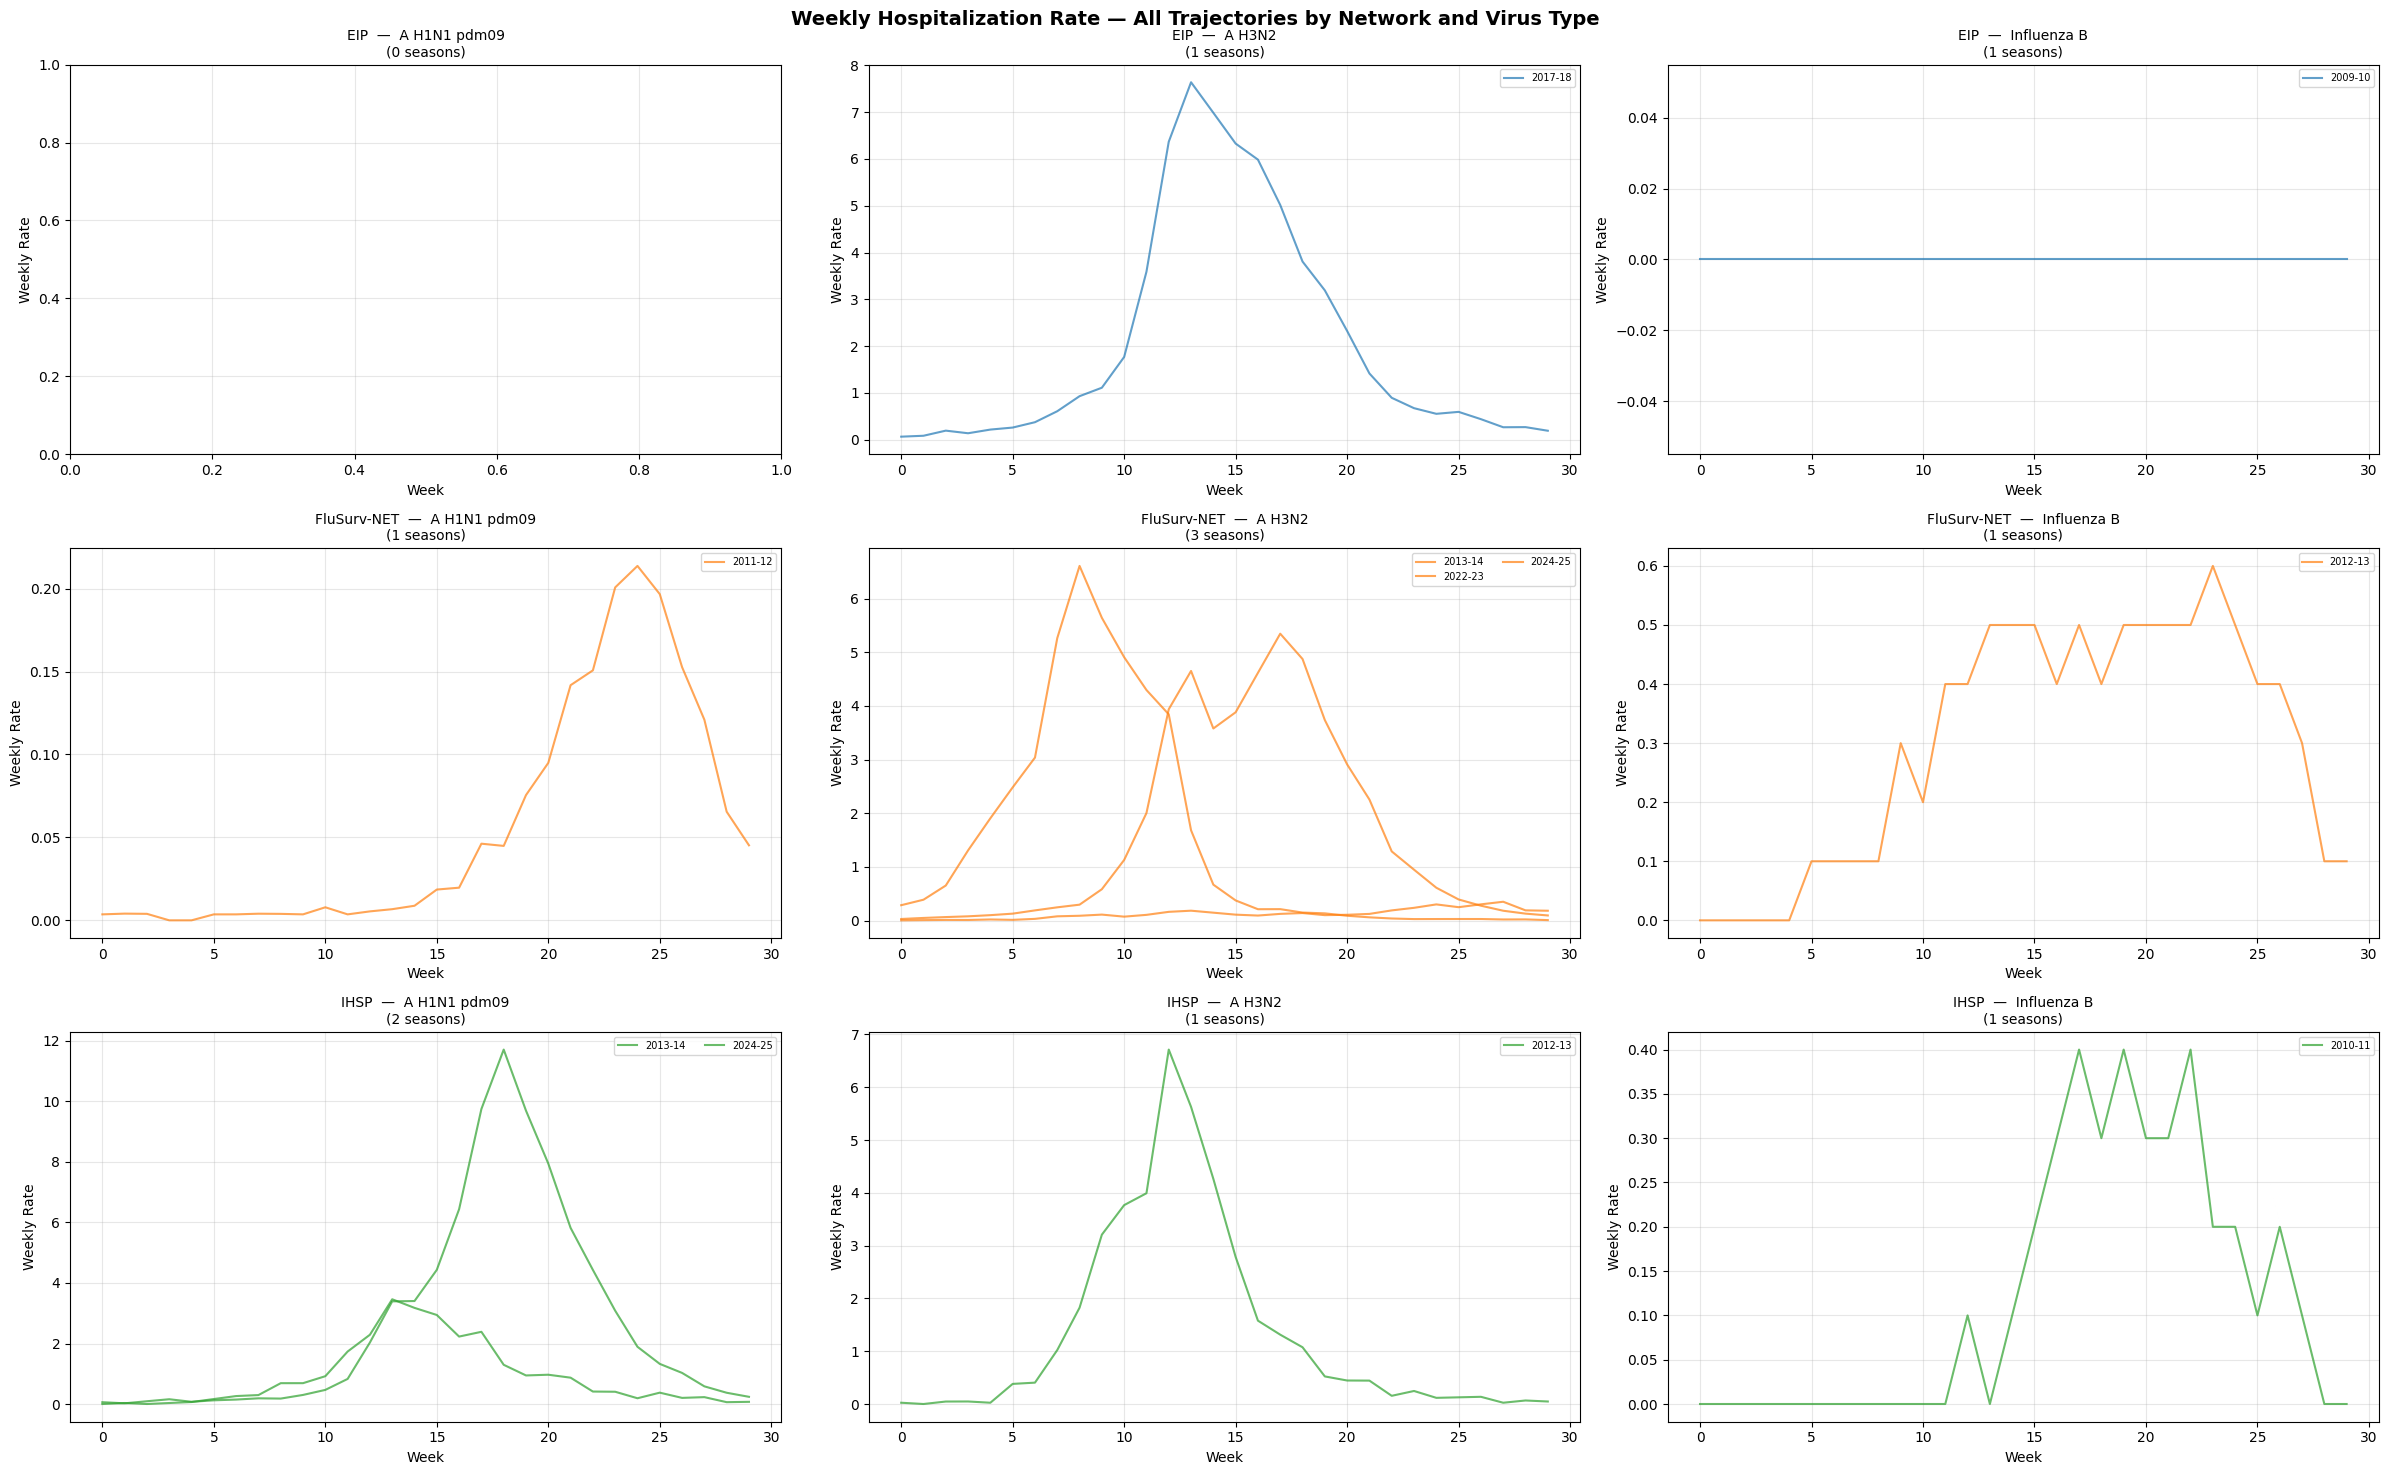

Saved: Subset/dataset_trajectories_by_network_virus.png


In [42]:
# ============================================================
# 1C. PLOT ALL TRAJECTORIES BY NETWORK AND VIRUS TYPE
# ============================================================

unique_networks = sorted({r["network"] for r in dataset_records})
unique_viruses  = sorted({r["virus"]   for r in dataset_records})
n_nets          = len(unique_networks)
n_virs          = len(unique_viruses)

fig, axes = plt.subplots(
    n_nets, n_virs,
    figsize=(8 * n_virs, 5 * n_nets),
    squeeze=False,
)

for row_idx, network in enumerate(unique_networks):
    for col_idx, virus in enumerate(unique_viruses):
        ax      = axes[row_idx][col_idx]
        records = [r for r in dataset_records
                   if r["network"] == network and r["virus"] == virus]

        for rec in records:
            ax.plot(rec["weeks"], rec["values"],
                    color=NETWORK_COLORS.get(network, "#999999"),
                    alpha=0.70, linewidth=1.5, label=rec["season"])

        n_traj = len(records)
        ax.set_title(f"{network}  —  {virus}\n({n_traj} seasons)", fontsize=10)
        ax.set_xlabel("Week")
        ax.set_ylabel("Weekly Rate")
        ax.grid(True, alpha=0.3)
        if 0 < n_traj <= 15:
            ax.legend(fontsize=7, ncol=2, loc="upper right")

DATASET_TRAJECTORIES_PNG = ROOT / "dataset_trajectories_by_network_virus.png"
fig.suptitle("Weekly Hospitalization Rate — All Trajectories by Network and Virus Type",
             fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(DATASET_TRAJECTORIES_PNG, dpi=300)
plt.show()
print(f"Saved: {DATASET_TRAJECTORIES_PNG}")


## 2. Two-Strain Vaccination ODE Model

*(Li, Cheng & Li, 2024)*

## Homogeneous Two-Strain Vaccination Model

$$
\frac{dS}{dt} = \Lambda - (\beta_1(t) I_1 + \beta_2(t) I_2 + \lambda)S
$$

$$
\frac{dV_1}{dt} = rS - (\mu + \sigma I_2)V_1
$$

$$
\frac{dI_1}{dt} = \beta_1(t) I_1 S - \alpha_1 I_1
$$

$$
\frac{dI_2}{dt} = \beta_2(t) I_2 S + \sigma I_2 V_1 - \alpha_2 I_2
$$

$$
\frac{dR}{dt} = \gamma_1 I_1 + \gamma_2 I_2 - \mu R
$$

where

$$
\lambda = r + \mu
$$

$$
\alpha_1 = \gamma_1 + \nu_1 + \mu
$$

$$
\alpha_2 = \gamma_2 + \nu_2 + \mu
$$

Here transmission is allowed to vary smoothly through time:

$$
\beta_i(t) = \beta_i \left[1 + a_i \exp\left(-\frac{1}{2}\left(\frac{t - \tau_i}{w_i}\right)^2\right)\right]
$$

where $a_i$ is the fitted seasonal boost, $\tau_i$ is the fitted peak week, and $w_i$ is the fitted width.

## Network Two-Strain Vaccination Model

For each degree group $k = 1,2,\dots,n$,

$$
\frac{dS_k}{dt} = \Lambda - \beta_1(t) k S_k \Theta_1 - \beta_2(t) k S_k \Theta_2 - \lambda S_k
$$

$$
\frac{dV_k}{dt} = rS_k - \mu V_k - \sigma k V_k \Theta_2
$$

$$
\frac{dI_k}{dt} = \beta_1(t) k S_k \Theta_1 - \alpha_1 I_k
$$

$$
\frac{dJ_k}{dt} = \beta_2(t) k S_k \Theta_2 + \sigma k V_k \Theta_2 - \alpha_2 J_k
$$

$$
\frac{dR_k}{dt} = \gamma_1 I_k + \gamma_2 J_k - \mu R_k
$$

where

$$
\lambda = r + \mu
$$

$$
\alpha_1 = \gamma_1 + \nu_1 + \mu
$$

$$
\alpha_2 = \gamma_2 + \nu_2 + \mu
$$

## Network Infection Pressure Terms

$$
\Theta_1(t) =
\frac{\sum_{h=1}^{n} hP(h)I_h(t)}
{\langle k \rangle}
$$

$$
\Theta_2(t) =
\frac{\sum_{h=1}^{n} hP(h)J_h(t)}
{\langle k \rangle}
$$

where

$$
\langle k \rangle = \sum_{h=1}^{n} hP(h)
$$

In [43]:
# ============================================================
# 2. ODE MODEL DEFINITIONS
# ============================================================

@dataclass
class PaperParams:
    beta1: float
    beta2: float
    sigma: float
    gamma1: float
    gamma2: float
    r: float
    mu: float
    nu1: float
    nu2: float
    Lambda: float
    rho1: float
    rho2: float
    I10: float
    I20: float
    V0: float = 0.0


def alpha1(p: PaperParams) -> float:
    return p.gamma1 + p.nu1 + p.mu


def alpha2(p: PaperParams) -> float:
    return p.gamma2 + p.nu2 + p.mu


def make_observed_beta_multiplier(values: np.ndarray) -> np.ndarray:
    """Build a fixed week-by-week beta multiplier from observed median rates."""
    values = np.asarray(values, dtype=float)
    values = np.maximum(values, 0.0)

    if BETA_MULTIPLIER_SMOOTH_WINDOW > 1:
        values = pd.Series(values).rolling(
            window=BETA_MULTIPLIER_SMOOTH_WINDOW,
            center=True,
            min_periods=1,
        ).mean().to_numpy(dtype=float)

    positive = values[values > 0]
    if len(positive) == 0:
        return np.ones_like(values, dtype=float)

    floor = max(float(np.min(positive)) * 0.50, 1e-6)
    safe_values = np.maximum(values, floor)
    growth = np.empty_like(safe_values, dtype=float)
    growth[:-1] = np.diff(np.log(safe_values))
    growth[-1] = growth[-2] if len(growth) > 1 else 0.0

    raw_multiplier = 1.0 + BETA_MULTIPLIER_GROWTH_GAIN * growth
    positive_raw = raw_multiplier[raw_multiplier > 0]
    if len(positive_raw) == 0:
        return np.ones_like(values, dtype=float)

    multiplier = raw_multiplier / float(np.mean(positive_raw))
    return np.clip(multiplier, BETA_MULTIPLIER_MIN, BETA_MULTIPLIER_MAX)


if USE_TIME_VARYING_BETA and "summary" in globals():
    BETA_TIME_GRID = summary["week"].to_numpy(dtype=float)
    BETA1_TIME_MULTIPLIER = make_observed_beta_multiplier(summary["median_strain1"].to_numpy(dtype=float))
    BETA2_TIME_MULTIPLIER = make_observed_beta_multiplier(summary["median_strain2"].to_numpy(dtype=float))
else:
    BETA_TIME_GRID = None
    BETA1_TIME_MULTIPLIER = None
    BETA2_TIME_MULTIPLIER = None


def beta_multiplier_at(t: float, multipliers: np.ndarray | None) -> float:
    if not USE_TIME_VARYING_BETA or BETA_TIME_GRID is None or multipliers is None:
        return 1.0
    idx = int(np.searchsorted(BETA_TIME_GRID, float(t), side="right") - 1)
    idx = int(np.clip(idx, 0, len(multipliers) - 1))
    return float(multipliers[idx])


def beta1_t(t: float, p: PaperParams) -> float:
    return p.beta1 * beta_multiplier_at(t, BETA1_TIME_MULTIPLIER)


def beta2_t(t: float, p: PaperParams) -> float:
    return p.beta2 * beta_multiplier_at(t, BETA2_TIME_MULTIPLIER)


def paper_homogeneous_rhs(t: float, y: np.ndarray, p: PaperParams) -> list[float]:
    """
    Paper's original aggregate two-strain vaccination model.

    y = [S, V, I1, I2, R]
    """
    S, V, I1, I2, R = y

    # Small numerical protection
    S = max(S, 0.0)
    V = max(V, 0.0)
    I1 = max(I1, 0.0)
    I2 = max(I2, 0.0)

    lam = p.r + p.mu
    b1 = beta1_t(t, p)
    b2 = beta2_t(t, p)

    new1 = b1 * I1 * S
    new2 = b2 * I2 * S + p.sigma * I2 * V

    dS = p.Lambda - (b1 * I1 + b2 * I2 + lam) * S
    dV = p.r * S - (p.mu + p.sigma * I2) * V
    dI1 = new1 - alpha1(p) * I1
    dI2 = new2 - alpha2(p) * I2
    dR = p.gamma1 * I1 + p.gamma2 * I2 - p.mu * R

    return [dS, dV, dI1, dI2, dR]


def paper_network_rhs(t: float, y: np.ndarray, p: PaperParams, degrees: np.ndarray, pk: np.ndarray) -> np.ndarray:
    """
    Paper's original complex-network model.

    For n degree classes, y stacks:
        S[0:n], V[0:n], I[0:n], J[0:n], R[0:n]
    """
    n = len(degrees)

    S = np.maximum(y[0:n], 0.0)
    V = np.maximum(y[n:2*n], 0.0)
    I = np.maximum(y[2*n:3*n], 0.0)
    J = np.maximum(y[3*n:4*n], 0.0)
    R = y[4*n:5*n]

    mean_k = np.sum(degrees * pk)
    theta1 = np.sum(degrees * pk * I) / mean_k
    theta2 = np.sum(degrees * pk * J) / mean_k

    lam = p.r + p.mu
    b1 = beta1_t(t, p)
    b2 = beta2_t(t, p)

    new1 = b1 * degrees * S * theta1
    new2 = b2 * degrees * S * theta2 + p.sigma * degrees * V * theta2

    dS = p.Lambda - b1 * degrees * S * theta1 - b2 * degrees * S * theta2 - lam * S
    dV = p.r * S - p.mu * V - p.sigma * degrees * V * theta2
    dI = new1 - alpha1(p) * I
    dJ = new2 - alpha2(p) * J
    dR = p.gamma1 * I + p.gamma2 * J - p.mu * R

    return np.concatenate([dS, dV, dI, dJ, dR])


def make_initial_state(p: PaperParams, model_version: str) -> np.ndarray:
    if p.I10 + p.I20 + p.V0 >= 0.95:
        raise ValueError("Initial fractions are too large: I10 + I20 + V0 must be < 0.95.")

    if model_version == "homogeneous":
        S0 = 1.0 - p.V0 - p.I10 - p.I20
        return np.array([S0, p.V0, p.I10, p.I20, 0.0], dtype=float)

    if model_version == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        n = len(degrees)

        S0 = np.full(n, 1.0 - p.V0 - p.I10 - p.I20, dtype=float)
        V0 = np.full(n, p.V0, dtype=float)
        I0 = np.full(n, p.I10, dtype=float)
        J0 = np.full(n, p.I20, dtype=float)
        R0 = np.zeros(n, dtype=float)

        return np.concatenate([S0, V0, I0, J0, R0])

    raise ValueError("model_version must be 'homogeneous' or 'network'.")


def simulate_paper_model(
    weeks: np.ndarray,
    p: PaperParams,
    model_version: str = MODEL_VERSION,
) -> pd.DataFrame:
    """
    Simulate the original two-strain model and return weekly predicted rates.

    Rates are scaled from the infected-state trajectories. For network simulations,
    infected states are aggregated over degree classes by P(k).
    """
    weeks = np.asarray(weeks, dtype=int)
    max_week = int(np.max(weeks))

    t_eval = np.arange(0, max_week + 1, dtype=float)
    y0 = make_initial_state(p, model_version)

    if model_version == "homogeneous":
        rhs = lambda t, y: paper_homogeneous_rhs(t, y, p)
    elif model_version == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()
        rhs = lambda t, y: paper_network_rhs(t, y, p, degrees, pk)
    else:
        raise ValueError("MODEL_VERSION must be 'homogeneous' or 'network'.")

    sol = solve_ivp(
        fun=rhs,
        t_span=(0.0, float(max_week)),
        y0=y0,
        t_eval=t_eval,
        method="LSODA",
        rtol=1e-6,
        atol=1e-8,
    )

    if not sol.success:
        raise RuntimeError(f"ODE solver failed: {sol.message}")

    if model_version == "homogeneous":
        strain1_all = np.maximum(sol.y[2, :], 0.0)
        strain2_all = np.maximum(sol.y[3, :], 0.0)

    else:
        n = len(DEGREES)
        I = np.maximum(sol.y[2*n:3*n, :], 0.0)
        J = np.maximum(sol.y[3*n:4*n, :], 0.0)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()

        strain1_all = np.sum(pk[:, None] * I, axis=0)
        strain2_all = np.sum(pk[:, None] * J, axis=0)

    pred1_all = p.rho1 * strain1_all
    pred2_all = p.rho2 * strain2_all

    out = pd.DataFrame({
        "week": weeks,
        "pred_strain1_rate": pred1_all[weeks],
        "pred_strain2_rate": pred2_all[weeks],
    })
    out["pred_total_rate"] = out["pred_strain1_rate"] + out["pred_strain2_rate"]
    return out


def reproduction_numbers(p: PaperParams) -> dict[str, float]:
    """
    Thresholds from the paper.

    For MODEL_VERSION = "homogeneous", <k^2>/<k> is set to 1.
    For MODEL_VERSION = "network", the network factor <k^2>/<k> is used.
    """
    lam = p.r + p.mu

    if lam <= 0:
        return {"R1": np.nan, "R2": np.nan}

    if MODEL_VERSION == "network":
        degrees = np.asarray(DEGREES, dtype=float)
        pk = np.asarray(P_K, dtype=float)
        pk = pk / pk.sum()
        network_factor = np.sum((degrees ** 2) * pk) / np.sum(degrees * pk)
    else:
        network_factor = 1.0

    R1 = (p.beta1 * p.Lambda / (alpha1(p) * lam)) * network_factor

    if p.mu > 0:
        R2 = (p.Lambda * (p.beta2 * p.mu + p.sigma * p.r) / (alpha2(p) * lam * p.mu)) * network_factor
    else:
        R2 = np.nan

    return {"R1": R1, "R2": R2}

## 3. Fit the ODE Model to Observed Data

In [44]:
# ============================================================
# 3. FITTING HELPERS
# ============================================================

def sigma_from_interval(
    lower: np.ndarray,
    upper: np.ndarray,
    z: float = 1.96,
) -> np.ndarray:
    diff = np.abs(np.asarray(upper, dtype=float) - np.asarray(lower, dtype=float))
    sigma = diff / (2.0 * z)
    return np.where(sigma > 1e-12, sigma, 1.0)


def has_two_strain_data(summary: pd.DataFrame) -> bool:
    return {"median_strain1", "median_strain2"}.issubset(summary.columns)


def build_fit_arrays(summary: pd.DataFrame) -> dict[str, np.ndarray]:
    weeks = summary["week"].to_numpy(dtype=int)

    if has_two_strain_data(summary) and not FIT_TO_TOTAL_ONLY:
        y1 = summary["median_strain1"].to_numpy(dtype=float)
        y2 = summary["median_strain2"].to_numpy(dtype=float)

        s1 = sigma_from_interval(
            summary["lower_95_strain1"].to_numpy(dtype=float),
            summary["upper_95_strain1"].to_numpy(dtype=float),
        )
        s2 = sigma_from_interval(
            summary["lower_95_strain2"].to_numpy(dtype=float),
            summary["upper_95_strain2"].to_numpy(dtype=float),
        )

        return {
            "mode": "two_strain",
            "weeks": weeks,
            "y1": y1,
            "y2": y2,
            "sigma1": s1,
            "sigma2": s2,
        }

    # Total-only fitting.
    if "median_total" in summary.columns:
        y_total = summary["median_total"].to_numpy(dtype=float)
        s_total = sigma_from_interval(
            summary["lower_95_total"].to_numpy(dtype=float),
            summary["upper_95_total"].to_numpy(dtype=float),
        )
    else:
        y_total = (
            summary["median_strain1"].to_numpy(dtype=float)
            + summary["median_strain2"].to_numpy(dtype=float)
        )
        s_total = np.sqrt(
            sigma_from_interval(summary["lower_95_strain1"].to_numpy(dtype=float), summary["upper_95_strain1"].to_numpy(dtype=float)) ** 2
            + sigma_from_interval(summary["lower_95_strain2"].to_numpy(dtype=float), summary["upper_95_strain2"].to_numpy(dtype=float)) ** 2
        )

    return {
        "mode": "total",
        "weeks": weeks,
        "y_total": y_total,
        "sigma_total": s_total,
    }


def make_params_from_theta(theta_log: np.ndarray, names: list[str]) -> PaperParams:
    values = dict(FIXED_VALUES)

    for name, z in zip(names, theta_log):
        values[name] = float(np.exp(z))

    missing = [
        name for name in [
            "beta1", "beta2", "sigma", "gamma1", "gamma2", "r",
            "mu", "nu1", "nu2", "Lambda", "rho1", "rho2", "I10", "I20", "V0"
        ]
        if name not in values
    ]
    if missing:
        raise ValueError(f"Missing parameter values: {missing}")

    return PaperParams(**values)


def theta_bounds(names: list[str]) -> tuple[np.ndarray, np.ndarray]:
    lower = []
    upper = []
    for name in names:
        if name not in PARAMETER_BOUNDS:
            raise ValueError(f"No bounds were provided for fitted parameter {name!r}.")
        lo, hi = PARAMETER_BOUNDS[name]
        if lo <= 0 or hi <= 0:
            raise ValueError("Log-space fitting requires strictly positive bounds.")
        lower.append(np.log(lo))
        upper.append(np.log(hi))

    return np.array(lower, dtype=float), np.array(upper, dtype=float)


def residuals_for_fit(theta_log: np.ndarray, fit_data: dict[str, np.ndarray]) -> np.ndarray:
    try:
        p = make_params_from_theta(theta_log, FIT_PARAMETER_NAMES)

        if p.I10 + p.I20 + p.V0 >= 0.95:
            return np.ones(10, dtype=float) * 1e8

        pred = simulate_paper_model(fit_data["weeks"], p, MODEL_VERSION)

        if fit_data["mode"] == "two_strain":
            r1 = pred["pred_strain1_rate"].to_numpy() - fit_data["y1"]
            r2 = pred["pred_strain2_rate"].to_numpy() - fit_data["y2"]

            if USE_WEIGHTED_FIT:
                r1 = r1 / fit_data["sigma1"]
                r2 = r2 / fit_data["sigma2"]

            return np.concatenate([r1, r2])

        r_total = pred["pred_total_rate"].to_numpy() - fit_data["y_total"]

        if USE_WEIGHTED_FIT:
            r_total = r_total / fit_data["sigma_total"]

        return r_total

    except Exception:
        n = len(fit_data["weeks"])
        if fit_data["mode"] == "two_strain":
            n *= 2
        return np.ones(n, dtype=float) * 1e8


def fit_cost(theta_log: np.ndarray, fit_data: dict[str, np.ndarray]) -> float:
    residuals = residuals_for_fit(theta_log, fit_data)
    if not np.all(np.isfinite(residuals)):
        return 1e300
    return float(0.5 * np.dot(residuals, residuals))


def fit_paper_model(summary: pd.DataFrame) -> tuple[PaperParams, pd.DataFrame, pd.DataFrame, dict]:
    fit_data = build_fit_arrays(summary)
    lower, upper = theta_bounds(FIT_PARAMETER_NAMES)
    bounds = list(zip(lower, upper))

    if DE_WORKERS > 1:
        with ThreadPoolExecutor(max_workers=DE_WORKERS) as pool:
            de_result = differential_evolution(
                func=fit_cost,
                bounds=bounds,
                args=(fit_data,),
                seed=RANDOM_SEED,
                maxiter=DE_MAXITER,
                popsize=DE_POPSIZE,
                tol=DE_TOL,
                polish=False,
                updating="deferred",
                workers=pool.map,
            )
    else:
        de_result = differential_evolution(
            func=fit_cost,
            bounds=bounds,
            args=(fit_data,),
            seed=RANDOM_SEED,
            maxiter=DE_MAXITER,
            popsize=DE_POPSIZE,
            tol=DE_TOL,
            polish=False,
            updating="immediate",
            workers=1,
        )

    local_result = least_squares(
        fun=lambda z: residuals_for_fit(z, fit_data),
        x0=np.clip(de_result.x, lower + 1e-12, upper - 1e-12),
        bounds=(lower, upper),
        method="trf",
        max_nfev=LOCAL_MAX_NFEV,
    )

    best_result = local_result
    best_params = make_params_from_theta(best_result.x, FIT_PARAMETER_NAMES)
    pred = simulate_paper_model(fit_data["weeks"], best_params, MODEL_VERSION)

    fit_df = pd.DataFrame({"week": fit_data["weeks"]})

    if fit_data["mode"] == "two_strain":
        fit_df[f"observed_{STRAIN1_NAME}_rate"] = fit_data["y1"]
        fit_df[f"observed_{STRAIN2_NAME}_rate"] = fit_data["y2"]
        fit_df[f"predicted_{STRAIN1_NAME}_rate"] = pred["pred_strain1_rate"].to_numpy()
        fit_df[f"predicted_{STRAIN2_NAME}_rate"] = pred["pred_strain2_rate"].to_numpy()
        fit_df["observed_total_rate"] = fit_data["y1"] + fit_data["y2"]
        fit_df[f"{STRAIN1_NAME}_residual"] = fit_df[f"predicted_{STRAIN1_NAME}_rate"] - fit_df[f"observed_{STRAIN1_NAME}_rate"]
        fit_df[f"{STRAIN2_NAME}_residual"] = fit_df[f"predicted_{STRAIN2_NAME}_rate"] - fit_df[f"observed_{STRAIN2_NAME}_rate"]
        fit_df[f"{STRAIN1_NAME}_absolute_error"] = np.abs(fit_df[f"{STRAIN1_NAME}_residual"])
        fit_df[f"{STRAIN2_NAME}_absolute_error"] = np.abs(fit_df[f"{STRAIN2_NAME}_residual"])
        fit_df[f"{STRAIN1_NAME}_squared_error"] = fit_df[f"{STRAIN1_NAME}_residual"] ** 2
        fit_df[f"{STRAIN2_NAME}_squared_error"] = fit_df[f"{STRAIN2_NAME}_residual"] ** 2
    else:
        fit_df["observed_total_rate"] = fit_data["y_total"]

    fit_df["predicted_total_rate"] = pred["pred_total_rate"].to_numpy()

    fit_df["total_residual"] = fit_df["predicted_total_rate"] - fit_df["observed_total_rate"]
    fit_df["total_absolute_error"] = np.abs(fit_df["total_residual"])
    fit_df["total_squared_error"] = fit_df["total_residual"] ** 2

    rmse_total = float(np.sqrt(np.mean(fit_df["total_squared_error"])))
    mae_total = float(np.mean(fit_df["total_absolute_error"]))

    rmse_strain1 = np.nan
    mae_strain1 = np.nan
    rmse_strain2 = np.nan
    mae_strain2 = np.nan
    if fit_data["mode"] == "two_strain":
        rmse_strain1 = float(np.sqrt(np.mean(fit_df[f"{STRAIN1_NAME}_squared_error"])))
        mae_strain1 = float(np.mean(fit_df[f"{STRAIN1_NAME}_absolute_error"]))
        rmse_strain2 = float(np.sqrt(np.mean(fit_df[f"{STRAIN2_NAME}_squared_error"])))
        mae_strain2 = float(np.mean(fit_df[f"{STRAIN2_NAME}_absolute_error"]))

    param_rows = []
    for key, value in asdict(best_params).items():
        param_rows.append({"parameter": key, "value": value, "source": "fitted" if key in FIT_PARAMETER_NAMES else "fixed"})

    param_rows.extend([
        {"parameter": f"RMSE_{STRAIN1_NAME}", "value": rmse_strain1, "source": "metric"},
        {"parameter": f"MAE_{STRAIN1_NAME}", "value": mae_strain1, "source": "metric"},
        {"parameter": f"RMSE_{STRAIN2_NAME}", "value": rmse_strain2, "source": "metric"},
        {"parameter": f"MAE_{STRAIN2_NAME}", "value": mae_strain2, "source": "metric"},
        {"parameter": "RMSE_total", "value": rmse_total, "source": "metric"},
        {"parameter": "MAE_total", "value": mae_total, "source": "metric"},
        {"parameter": "weighted_cost", "value": best_result.cost, "source": "metric"},
        {"parameter": "optimizer_success", "value": bool(best_result.success), "source": "metric"},
        {"parameter": "optimizer_message", "value": str(best_result.message), "source": "metric"},
        {"parameter": "optimizer_method", "value": "differential_evolution_parallel_then_least_squares", "source": "setting"},
        {"parameter": "de_cost", "value": float(de_result.fun), "source": "metric"},
        {"parameter": "de_success", "value": bool(de_result.success), "source": "metric"},
        {"parameter": "de_message", "value": str(de_result.message), "source": "metric"},
        {"parameter": "de_nit", "value": int(de_result.nit), "source": "metric"},
        {"parameter": "de_nfev", "value": int(de_result.nfev), "source": "metric"},
        {"parameter": "de_workers", "value": int(DE_WORKERS), "source": "setting"},
        {"parameter": "local_cost", "value": float(local_result.cost), "source": "metric"},
        {"parameter": "local_success", "value": bool(local_result.success), "source": "metric"},
        {"parameter": "local_message", "value": str(local_result.message), "source": "metric"},
        {"parameter": "local_nfev", "value": int(local_result.nfev), "source": "metric"},
        {"parameter": "MODEL_VERSION", "value": MODEL_VERSION, "source": "setting"},
        {"parameter": "fit_mode", "value": fit_data["mode"], "source": "setting"},
        {"parameter": "USE_TIME_VARYING_BETA", "value": bool(USE_TIME_VARYING_BETA), "source": "setting"},
        {"parameter": "BETA_MULTIPLIER_SMOOTH_WINDOW", "value": int(BETA_MULTIPLIER_SMOOTH_WINDOW), "source": "setting"},
        {"parameter": "BETA_MULTIPLIER_GROWTH_GAIN", "value": float(BETA_MULTIPLIER_GROWTH_GAIN), "source": "setting"},
        {"parameter": "BETA_MULTIPLIER_MIN", "value": float(BETA_MULTIPLIER_MIN), "source": "setting"},
        {"parameter": "BETA_MULTIPLIER_MAX", "value": float(BETA_MULTIPLIER_MAX), "source": "setting"},
    ])

    for key, value in reproduction_numbers(best_params).items():
        param_rows.append({"parameter": key, "value": value, "source": "threshold"})

    param_df = pd.DataFrame(param_rows)

    metrics = {
        "fit_mode": fit_data["mode"],
        "rmse_strain1": rmse_strain1,
        "mae_strain1": mae_strain1,
        "rmse_strain2": rmse_strain2,
        "mae_strain2": mae_strain2,
        "rmse_total": rmse_total,
        "mae_total": mae_total,
        "weighted_cost": float(best_result.cost),
        "optimizer_success": bool(best_result.success),
        "optimizer_message": str(best_result.message),
        "optimizer_method": "differential_evolution_parallel_then_least_squares",
        "de_cost": float(de_result.fun),
        "de_success": bool(de_result.success),
        "de_message": str(de_result.message),
        "de_nit": int(de_result.nit),
        "de_nfev": int(de_result.nfev),
        "de_workers": int(DE_WORKERS),
        "local_cost": float(local_result.cost),
        "local_success": bool(local_result.success),
        "local_message": str(local_result.message),
        "local_nfev": int(local_result.nfev),
        "use_time_varying_beta": bool(USE_TIME_VARYING_BETA),
        "beta_multiplier_smooth_window": int(BETA_MULTIPLIER_SMOOTH_WINDOW),
        "beta_multiplier_growth_gain": float(BETA_MULTIPLIER_GROWTH_GAIN),
        "beta_multiplier_min": float(BETA_MULTIPLIER_MIN),
        "beta_multiplier_max": float(BETA_MULTIPLIER_MAX),
    }

    return best_params, fit_df, param_df, metrics

## Section 3B — Fit ODE to Each Season Separately
Runs differential evolution + local least-squares on every individual trajectory in `Dataset/`.  
Results are cached in `Dataset/season_fit_parameters.csv`; set `REFIT_SEASONS = True` to rerun.

In [45]:
# ============================================================
# 3B. FIT ODE TO EACH SEASON SEPARATELY
# ============================================================
# Each trajectory in season_curves (= dataset_records, one file per
# network / season / virus) gets its own ODE fit using the total-rate
# mode.  This produces 105 independent PaperParams baselines that
# Section 4 will perturb to generate the synthetic dataset.

def fit_ode_to_curve(
    weeks: np.ndarray,
    values: np.ndarray,
    de_maxiter: int = SEASON_DE_MAXITER,
    de_popsize: int = SEASON_DE_POPSIZE,
    de_tol: float = SEASON_DE_TOL,
    de_workers: int = SEASON_DE_WORKERS,
    local_max_nfev: int = SEASON_LOCAL_MAX_NFEV,
    seed: int = RANDOM_SEED,
) -> tuple:
    lower, upper = theta_bounds(FIT_PARAMETER_NAMES)
    bounds = list(zip(lower, upper))

    fit_data = {
        "mode":        "total",
        "weeks":       weeks,
        "y_total":     values,
        "sigma_total": np.ones_like(values, dtype=float),
    }

    if de_workers > 1:
        with ThreadPoolExecutor(max_workers=de_workers) as pool:
            de_result = differential_evolution(
                func=fit_cost, bounds=bounds, args=(fit_data,),
                seed=seed, maxiter=de_maxiter, popsize=de_popsize,
                tol=de_tol, polish=False, updating="deferred", workers=pool.map,
            )
    else:
        de_result = differential_evolution(
            func=fit_cost, bounds=bounds, args=(fit_data,),
            seed=seed, maxiter=de_maxiter, popsize=de_popsize,
            tol=de_tol, polish=False, updating="immediate", workers=1,
        )

    local_result = least_squares(
        fun=lambda z: residuals_for_fit(z, fit_data),
        x0=np.clip(de_result.x, lower + 1e-12, upper - 1e-12),
        bounds=(lower, upper),
        method="trf",
        max_nfev=local_max_nfev,
    )

    params = make_params_from_theta(local_result.x, FIT_PARAMETER_NAMES)
    pred   = simulate_paper_model(weeks, params, MODEL_VERSION)
    rmse   = float(np.sqrt(np.mean(
        (pred["pred_total_rate"].to_numpy() - values) ** 2
    )))
    info   = {
        "de_cost":    float(de_result.fun),
        "de_nit":     int(de_result.nit),
        "local_cost": float(local_result.cost),
        "success":    bool(local_result.success),
    }
    return params, rmse, info


def fit_all_curves(curves: list) -> pd.DataFrame:
    rows = []
    for i, curve in enumerate(curves):
        print(f"  [{i+1}/{len(curves)}] {curve['label']} ...", end=" ", flush=True)
        try:
            params, rmse, info = fit_ode_to_curve(
                curve["weeks"], curve["values"], seed=RANDOM_SEED + i
            )
            row = {
                "label":   curve["label"],
                "network": curve["network"],
                "season":  curve["season"],
                "virus":   curve["virus"],
                "rmse":    rmse,
            }
            row.update(info)
            row.update(asdict(params))
            rows.append(row)
            print(f"RMSE={rmse:.4f}")
        except Exception as e:
            print(f"FAILED: {e}")
    return pd.DataFrame(rows)


if SEASON_FITS_CSV.exists() and not REFIT_SEASONS:
    season_fits_df = pd.read_csv(SEASON_FITS_CSV)
    print(f"Loaded {len(season_fits_df)} cached fits from {SEASON_FITS_CSV}")
else:
    print(f"Fitting ODE to {len(season_curves)} individual trajectories ...")
    season_fits_df = fit_all_curves(season_curves)
    season_fits_df.to_csv(SEASON_FITS_CSV, index=False)
    print(f"Saved to {SEASON_FITS_CSV}")

print(f"\nRMSE  min={season_fits_df['rmse'].min():.4f}  "
      f"max={season_fits_df['rmse'].max():.4f}  "
      f"mean={season_fits_df['rmse'].mean():.4f}")
display(season_fits_df[["label", "network", "season", "virus", "rmse"]].head(10))


Loaded 11 cached fits from Subset/season_fit_parameters.csv

RMSE  min=0.0000  max=0.4148  mean=0.1759


,label,network,season,virus,rmse
0,EIP_2009-10_Influenza_B,EIP,2009-10,Influenza B,3.791276e-19
1,EIP_2017-18_A_H3N2,EIP,2017-18,A H3N2,1.750200e-01
2,FluSurv-NET_2011-12_A_H1N1_pdm09,FluSurv-NET,2011-12,A H1N1 pdm09,5.263309e-03
3,FluSurv-NET_2012-13_Influenza_B,FluSurv-NET,2012-13,Influenza B,7.138182e-02
4,FluSurv-NET_2013-14_A_H3N2,FluSurv-NET,2013-14,A H3N2,4.731872e-02
5,FluSurv-NET_2022-23_A_H3N2,FluSurv-NET,2022-23,A H3N2,3.175893e-01
6,FluSurv-NET_2024-25_A_H3N2,FluSurv-NET,2024-25,A H3N2,3.924240e-01
7,IHSP_2010-11_Influenza_B,IHSP,2010-11,Influenza B,4.346132e-02
8,IHSP_2012-13_A_H3N2,IHSP,2012-13,A H3N2,3.237405e-01
9,IHSP_2013-14_A_H1N1_pdm09,IHSP,2013-14,A H1N1 pdm09,1.440620e-01


## Section 3C — Per-Season Fit Quality Plot
Solid = observed trajectory, dashed = ODE fit.  One subplot per (network, virus type).

/var/folders/pm/bk3q9c513yg83822gmfz13780000gn/T/ipykernel_64399/1424960449.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, ncol=2)


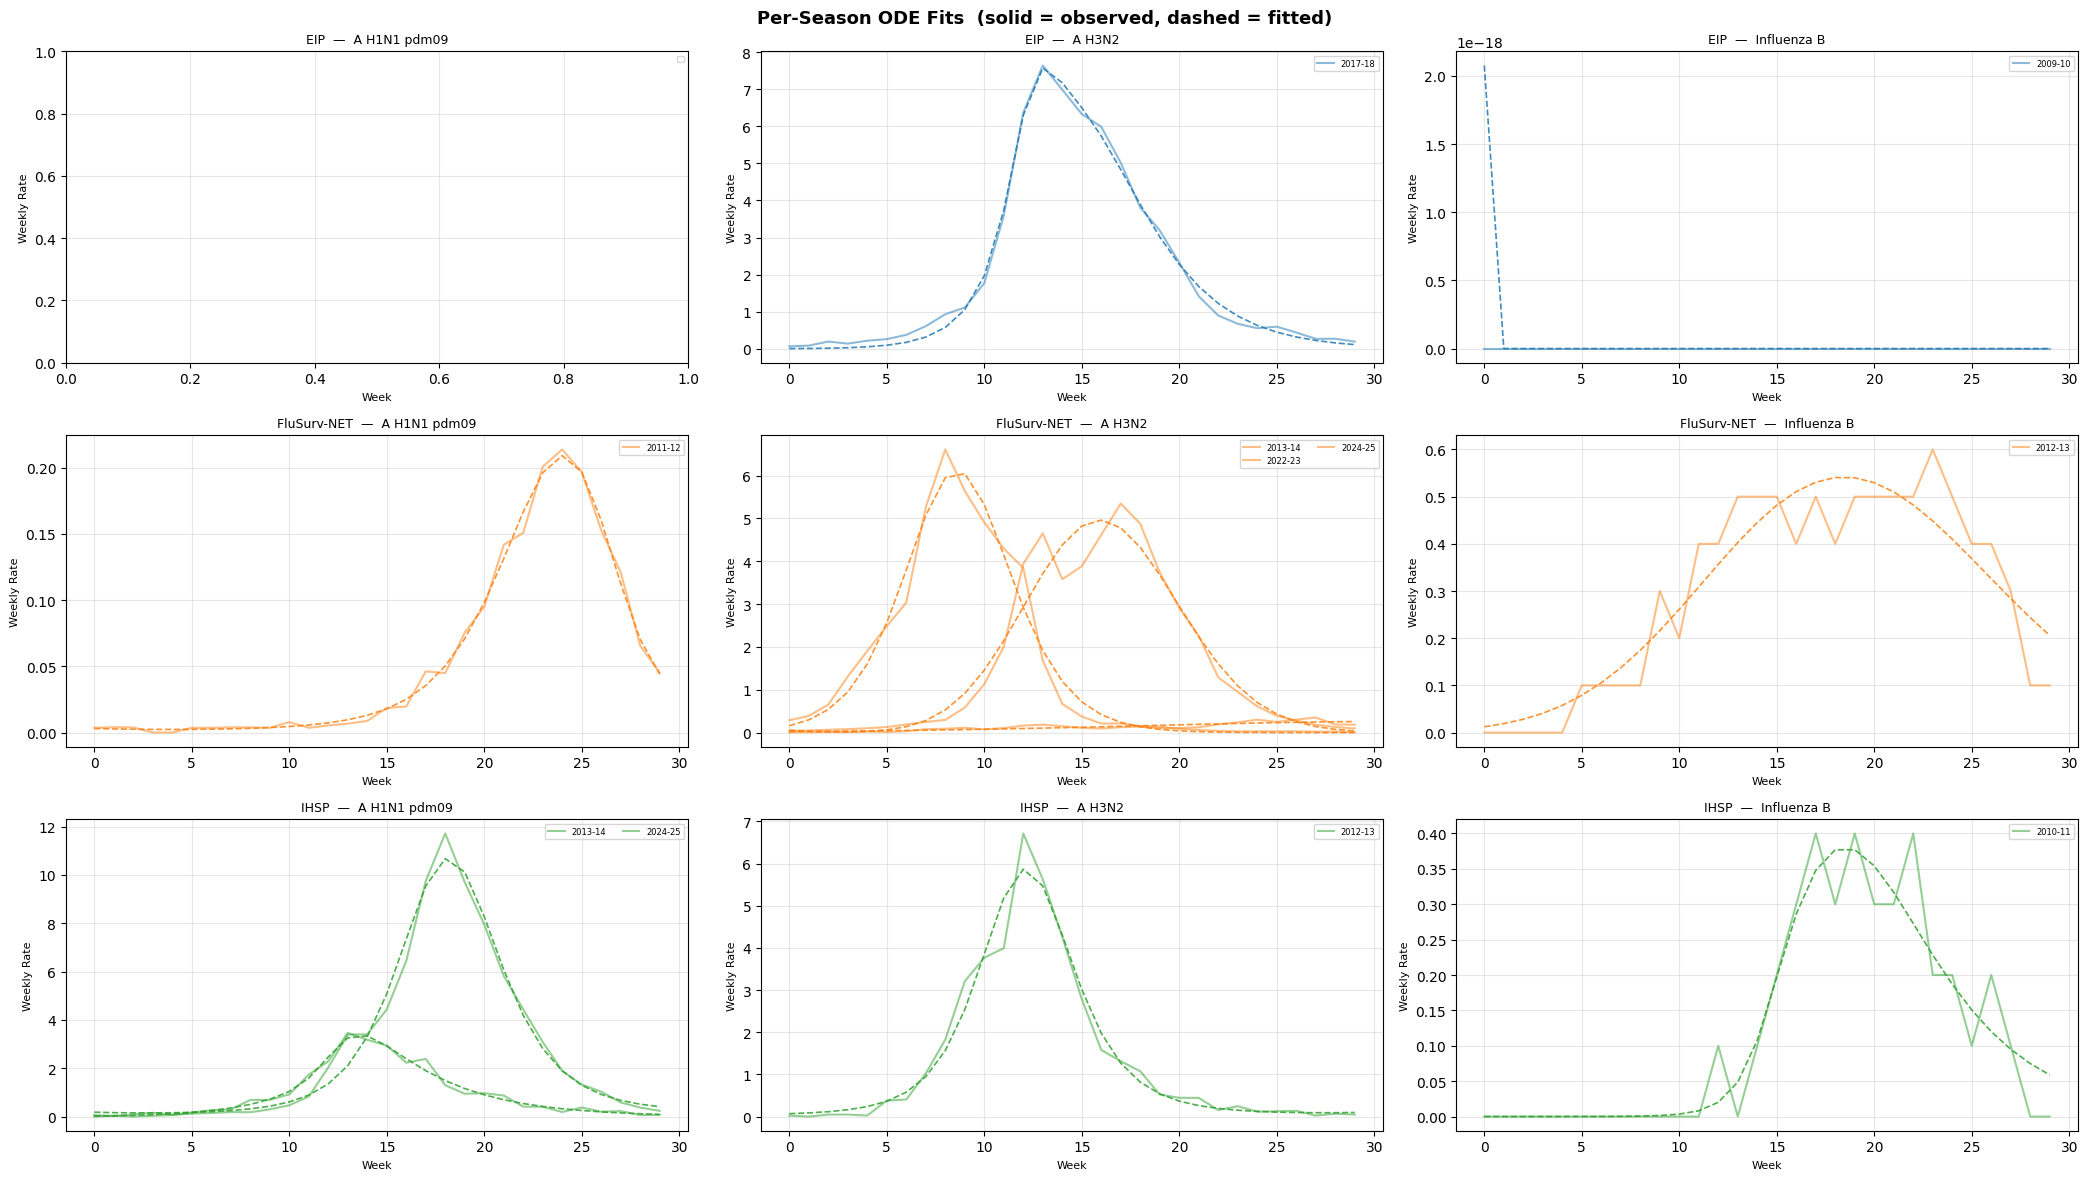

Saved: Subset/per_season_fits.png


In [46]:
# ============================================================
# 3C. PER-SEASON FIT QUALITY PLOT
# ============================================================

unique_networks = sorted({c["network"] for c in season_curves})
unique_viruses  = sorted({c["virus"]   for c in season_curves})
n_nets = len(unique_networks)
n_virs = len(unique_viruses)

fits_by_label = season_fits_df.set_index("label").to_dict("index")

fig, axes = plt.subplots(n_nets, n_virs,
                          figsize=(7 * n_virs, 4 * n_nets), squeeze=False)

for ri, network in enumerate(unique_networks):
    for ci, virus in enumerate(unique_viruses):
        ax = axes[ri][ci]
        network_virus_curves = [
            crv for crv in season_curves
            if crv["network"] == network and crv["virus"] == virus
        ]
        for crv in network_virus_curves:
            row = fits_by_label.get(crv["label"])
            if row is None:
                continue
            params = PaperParams(**{k: float(row[k]) for k in PAPER_PARAM_FIELD_NAMES})
            pred   = simulate_paper_model(crv["weeks"], params, MODEL_VERSION)
            color  = NETWORK_COLORS.get(network, "#555")
            ax.plot(crv["weeks"], crv["values"], color=color, alpha=0.5,
                    linewidth=1.5, label=crv["season"])
            ax.plot(crv["weeks"], pred["pred_total_rate"].to_numpy(), "--",
                    color=color, alpha=0.85, linewidth=1.2)
        ax.set_title(f"{network}  —  {virus}", fontsize=9)
        ax.set_xlabel("Week", fontsize=8)
        ax.set_ylabel("Weekly Rate", fontsize=8)
        ax.grid(True, alpha=0.3)
        if len(network_virus_curves) <= 15:
            ax.legend(fontsize=6, ncol=2)

FIT_SEASONS_PNG = ROOT / "per_season_fits.png"
fig.suptitle("Per-Season ODE Fits  (solid = observed, dashed = fitted)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIT_SEASONS_PNG, dpi=200)
plt.show()
print(f"Saved: {FIT_SEASONS_PNG}")


### 3F. Build Per-Week Observed Bounds Envelope

In [47]:
# ============================================================
# 3F. OBSERVED BOUNDS AND PERTURBATION HELPERS
# ============================================================
# Shared by both the Parameter Perturb preview and section 4's virtual
# dataset generation: the per-week min/max envelope every generated
# trajectory must stay within, plus the perturbation / rejection-sampling
# machinery itself.

def perturb_params(
    p: PaperParams,
    amount: float,
    rng: np.random.Generator,
    names_to_perturb: list[str] | None = None,
    amount_by_param: dict[str, float] | None = None,
) -> tuple[PaperParams, dict[str, float]]:
    """
    Perturb each selected fitted parameter independently from the fitted baseline.

    `amount` is the default fraction, so PERTURB_AMOUNT = 0.80 means each
    parameter gets its own random change inside +/-80%. `amount_by_param` lets
    specific parameters (e.g. beta1, gamma1, I10) use a wider or narrower
    range than the default, so the virtual dataset spans a bigger variety of
    peak heights, peak timings, and rise/fall speeds.
    """
    if names_to_perturb is None:
        names_to_perturb = list(globals().get("PERTURB_PARAMETER_NAMES", FIT_PARAMETER_NAMES))
    if amount_by_param is None:
        amount_by_param = {}

    values = asdict(p)
    perturb_percent_by_param = {}

    for name in names_to_perturb:
        if name not in values:
            raise ValueError(f"Unknown parameter: {name}")
        if name not in PARAMETER_BOUNDS:
            raise ValueError(f"No bounds were provided for parameter: {name}")

        baseline_value = float(values[name])
        lo, hi = PARAMETER_BOUNDS[name]
        param_amount = amount_by_param.get(name, amount)
        sampled_fraction = float(rng.uniform(-param_amount, param_amount))
        sampled_percent = 100.0 * sampled_fraction
        sampled_value = baseline_value * (1.0 + sampled_fraction)

        values[name] = float(np.clip(sampled_value, lo, hi))
        perturb_percent_by_param[name] = sampled_percent

    if values["I10"] + values["I20"] + values["V0"] >= 0.95:
        scale = 0.90 / (values["I10"] + values["I20"] + values["V0"])
        values["I10"] *= scale
        values["I20"] *= scale
        values["V0"] *= scale

    return PaperParams(**values), perturb_percent_by_param



def perturbation_signature(
    p_virtual: PaperParams,
    perturb_percent_by_param: dict[str, float],
    names_to_perturb: list[str],
    decimals: int = PERTURBATION_SIGNATURE_DECIMALS,
) -> tuple:
    """Build a rounded signature so every accepted perturbation combination can be unique."""
    values = asdict(p_virtual)
    return tuple(
        (name, round(float(values[name]), decimals), round(float(perturb_percent_by_param.get(name, 0.0)), decimals))
        for name in names_to_perturb
    )



def trajectory_mean_weekly_rate(
    pred: pd.DataFrame,
    rate_col: str = "pred_total_rate",
) -> float:
    return float(pred[rate_col].mean())


def widen_observed_bounds(
    observed_bounds: pd.DataFrame,
    slack_fraction: float,
) -> pd.DataFrame:
    """
    Widen each min/max observed-bound pair by `slack_fraction` of its width on
    each side. With slack_fraction=0.0 this is a no-op (the original
    behavior). A positive value lets create_virtual_dataset accept
    trajectories whose peak height, peak timing, or rise/fall speed differs
    from the single observed season, without disabling the sanity check
    entirely.
    """
    widened = observed_bounds.copy()
    bound_pairs = [
        ("min_observed_strain1", "max_observed_strain1"),
        ("min_observed_strain2", "max_observed_strain2"),
        ("min_observed_total", "max_observed_total"),
    ]

    for min_col, max_col in bound_pairs:
        if min_col not in widened.columns or max_col not in widened.columns:
            continue
        width = widened[max_col] - widened[min_col]
        slack = slack_fraction * width
        widened[min_col] = (widened[min_col] - slack).clip(lower=0.0)
        widened[max_col] = widened[max_col] + slack

    return widened


def trajectory_stays_within_observed_bounds(
    pred: pd.DataFrame,
    observed_bounds: pd.DataFrame,
    tolerance: float = OBSERVED_BOUND_TOLERANCE,
) -> bool:
    """Return True when the simulated trajectory stays inside the relevant observed min/max band."""
    total_checks = [("pred_total_rate", "min_observed_total", "max_observed_total")]
    strain_checks = [
        ("pred_strain1_rate", "min_observed_strain1", "max_observed_strain1"),
        ("pred_strain2_rate", "min_observed_strain2", "max_observed_strain2"),
    ]

    has_total_bounds = {"min_observed_total", "max_observed_total"}.issubset(observed_bounds.columns)
    has_strain_bounds = {
        "min_observed_strain1", "max_observed_strain1",
        "min_observed_strain2", "max_observed_strain2",
    }.issubset(observed_bounds.columns)

    if FIT_TO_TOTAL_ONLY or not has_strain_bounds:
        checks = total_checks
    else:
        checks = strain_checks
        if has_total_bounds:
            checks = checks + total_checks

    pred_cols = [pred_col for pred_col, _, _ in checks]
    bound_cols = ["week"] + [col for _, lower_col, upper_col in checks for col in [lower_col, upper_col]]
    missing_pred = [col for col in pred_cols if col not in pred.columns]
    missing_bounds = [col for col in bound_cols if col not in observed_bounds.columns]
    if missing_pred:
        raise ValueError(f"Missing prediction columns: {missing_pred}")
    if missing_bounds:
        raise ValueError(f"Missing observed-bound columns: {missing_bounds}")

    check = pred[["week"] + pred_cols].merge(
        observed_bounds[bound_cols],
        on="week",
        how="left",
        validate="one_to_one",
    )

    missing_week_bounds = check[bound_cols[1:]].isna().any(axis=1)
    if missing_week_bounds.any():
        missing_weeks = check.loc[missing_week_bounds, "week"].tolist()
        raise ValueError(f"No observed min/max bounds for weeks: {missing_weeks}")

    inside = np.ones(len(check), dtype=bool)
    for pred_col, lower_col, upper_col in checks:
        inside &= (
            (check[pred_col] >= check[lower_col] - tolerance)
            & (check[pred_col] <= check[upper_col] + tolerance)
        )

    return bool(inside.all())


def create_virtual_dataset(
    p: PaperParams,
    weeks: np.ndarray,
    n_trajectories: int,
    perturb_amount: float,
    seed: int,
    observed_bounds: pd.DataFrame | None = None,
    enforce_bounds: bool = ENFORCE_OBSERVED_MIN_MAX_BOUNDS,
    max_attempts: int = MAX_VIRTUAL_GENERATION_ATTEMPTS,
    amount_by_param: dict[str, float] | None = None,
    used_perturbation_signatures: set[tuple] | None = None,
    require_unique_perturbations: bool = REQUIRE_UNIQUE_SYNTHETIC_PERTURBATIONS,
    min_mean_weekly_rate: float = MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE,
    baseline_label: str | None = None,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    rows = []
    accepted = 0
    attempts = 0
    rejected = 0
    rejected_duplicate = 0
    rejected_low_average = 0

    if used_perturbation_signatures is None:
        used_perturbation_signatures = set()

    if enforce_bounds and observed_bounds is None:
        raise ValueError("observed_bounds is required when enforce_bounds=True.")

    while accepted < n_trajectories and attempts < max_attempts:
        attempts += 1
        p_virtual, perturb_percent_by_param = perturb_params(
            p,
            perturb_amount,
            rng,
            names_to_perturb=PERTURB_PARAMETER_NAMES,
            amount_by_param=amount_by_param,
        )
        signature = perturbation_signature(
            p_virtual,
            perturb_percent_by_param,
            PERTURB_PARAMETER_NAMES,
            PERTURBATION_SIGNATURE_DECIMALS,
        )
        if require_unique_perturbations and signature in used_perturbation_signatures:
            rejected += 1
            rejected_duplicate += 1
            continue

        pred = simulate_paper_model(weeks, p_virtual, MODEL_VERSION)
        trajectory_mean_total_rate = trajectory_mean_weekly_rate(pred, "pred_total_rate")
        if min_mean_weekly_rate is not None and trajectory_mean_total_rate < min_mean_weekly_rate:
            rejected += 1
            rejected_low_average += 1
            continue

        if enforce_bounds and not trajectory_stays_within_observed_bounds(pred, observed_bounds):
            rejected += 1
            continue

        if require_unique_perturbations:
            used_perturbation_signatures.add(signature)

        accepted += 1
        virtual_id = accepted

        for _, row in pred.iterrows():
            rows.append({
                "virtual_id": virtual_id,
                "generation_attempt": attempts,
                "trajectory_mean_total_rate": trajectory_mean_total_rate,
                "week": int(row["week"]),
                "virtual_strain1_rate": float(row["pred_strain1_rate"]),
                "virtual_strain2_rate": float(row["pred_strain2_rate"]),
                "virtual_total_rate": float(row["pred_total_rate"]),
                "beta1": p_virtual.beta1,
                "beta2": p_virtual.beta2,
                "sigma": p_virtual.sigma,
                "gamma1": p_virtual.gamma1,
                "gamma2": p_virtual.gamma2,
                "r": p_virtual.r,
                "mu": p_virtual.mu,
                "nu1": p_virtual.nu1,
                "nu2": p_virtual.nu2,
                "Lambda": p_virtual.Lambda,
                "rho1": p_virtual.rho1,
                "rho2": p_virtual.rho2,
                "I10": p_virtual.I10,
                "I20": p_virtual.I20,
                "V0": p_virtual.V0,
                **{f"{name}_perturb_percent": perturb_percent_by_param.get(name, 0.0) for name in PAPER_PARAM_FIELD_NAMES},
            })

    if accepted < n_trajectories:
        baseline_text = f" for {baseline_label}" if baseline_label else ""
        print(
            f"Warning{baseline_text}: accepted only {accepted} of {n_trajectories} requested trajectories after "
            f"{attempts} attempts. Try lowering perturbation amounts, lowering "
            "MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE, widening OBSERVED_BOUND_SLACK_FRACTION, "
            "or increasing max_attempts."
        )

    virtual_df = pd.DataFrame(rows)
    virtual_df.attrs["accepted_trajectories"] = accepted
    virtual_df.attrs["generation_attempts"] = attempts
    virtual_df.attrs["rejected_trajectories"] = rejected
    virtual_df.attrs["rejected_duplicate_perturbations"] = rejected_duplicate
    virtual_df.attrs["rejected_low_average_trajectories"] = rejected_low_average
    return virtual_df



# ============================================================
# Build observed bounds and week axis for rejection sampling
# ============================================================
# observed_bounds was built from individual trajectory files in Section 1B.
# Apply slack widening here so downstream cells always use widened bounds.
observed_bounds = widen_observed_bounds(observed_bounds, OBSERVED_BOUND_SLACK_FRACTION)

weeks = fit_weeks   # shared week axis from Section 1B

print("Observed bounds (per-week min/max envelope used for rejection sampling):")
display(observed_bounds.head())


Observed bounds (per-week min/max envelope used for rejection sampling):


,week,min_observed_strain1,max_observed_strain1,min_observed_strain2,max_observed_strain2,min_observed_total,max_observed_total
0,0,0.0,0.286685,0.0,0.0,0.0,0.286685
1,1,0.0,0.389129,0.0,0.0,0.0,0.389129
2,2,0.0,0.653470,0.0,0.0,0.0,0.653470
3,3,0.0,1.308540,0.0,0.0,0.0,1.308540
4,4,0.0,1.907460,0.0,0.0,0.0,1.907460


## 4. Generate Perturbation Virtual Trajectories

For each fitted season baseline, randomly perturb the ODE parameters within the bounds defined in Section 0. Trajectories are accepted only if they stay inside the observed min/max envelope and exceed the minimum mean weekly rate.

In [48]:
# ============================================================
# 4. VIRTUAL DATASET FROM PERTURBED PAPER MODEL
# ============================================================

def make_virtual_patients_by_strain(
    virtual_df: pd.DataFrame,
    obs_bounds: pd.DataFrame,
) -> pd.DataFrame:
    """Split joint two-strain virtual trajectories into per-strain patient records."""
    parameter_cols = [
        "beta1", "beta2", "sigma", "gamma1", "gamma2", "r", "mu",
        "nu1", "nu2", "Lambda", "rho1", "rho2", "I10", "I20", "V0",
    ]
    perturb_percent_cols = [f"{name}_perturb_percent" for name in PAPER_PARAM_FIELD_NAMES]
    parameter_cols = parameter_cols + [col for col in perturb_percent_cols if col in virtual_df.columns]
    if "source_baseline" in virtual_df.columns:
        parameter_cols = parameter_cols + ["source_baseline"]

    strain_specs = [
        {"strain": STRAIN1_NAME, "strain_id": "A", "rate_col": "virtual_strain1_rate"},
        {"strain": STRAIN2_NAME, "strain_id": "B", "rate_col": "virtual_strain2_rate"},
    ]

    def baseline_strain_id(label: str) -> str | None:
        normalized = str(label).lower()
        if "influenza_b" in normalized or "influenza b" in normalized or "influenzab" in normalized:
            return "B"
        if "influenza_a" in normalized or "influenza a" in normalized or "influenzaa" in normalized or "a_h1n1" in normalized or "a_h3n2" in normalized:
            return "A"
        return None

    # Attach total observed bounds as metadata on each patient row
    bound_cols = [c for c in ["week", "min_observed_total", "max_observed_total"]
                  if c in obs_bounds.columns]
    bound_lookup = obs_bounds[bound_cols].copy()

    patient_frames = []
    for spec in strain_specs:
        cols = (["virtual_id", "generation_attempt", "trajectory_mean_total_rate", "week", spec["rate_col"]]
                + parameter_cols)
        temp = virtual_df[[c for c in cols if c in virtual_df.columns]].copy()
        if "source_baseline" in temp.columns:
            source_strain = temp["source_baseline"].map(baseline_strain_id)
            temp = temp[source_strain.isna() | source_strain.eq(spec["strain_id"])].copy()
            if temp.empty:
                continue
        temp = temp.rename(columns={spec["rate_col"]: "virtual_WEEKLY_RATE"})
        temp["strain"] = spec["strain"]
        temp["strain_id"] = spec["strain_id"]
        temp["virtual_patient_id"] = (
            temp["strain_id"] + "_" + temp["virtual_id"].astype(str).str.zfill(5)
        )
        if len(bound_cols) > 1:
            temp = temp.merge(bound_lookup, on="week", how="left", validate="many_to_one")
        patient_frames.append(temp)

    patients = pd.concat(patient_frames, ignore_index=True)
    patients = patients.sort_values(["strain", "virtual_id", "week"]).reset_index(drop=True)
    return patients


# Baselines: one per individually-fitted season curve (from Section 3B)
baselines = [
    (row["label"], PaperParams(**{k: float(row[k]) for k in PAPER_PARAM_FIELD_NAMES}))
    for _, row in season_fits_df.iterrows()
]
if not baselines:
    raise RuntimeError("season_fits_df is empty — run Section 3B first.")

n_baselines = len(baselines)

virtual_frames = []
next_virtual_id = 0
total_attempts = 0
total_rejected = 0

total_rejected_duplicate = 0

total_rejected_low_average = 0

used_perturbation_signatures = set()
incomplete_baselines = []

for i, (baseline_label, baseline_params) in enumerate(baselines):
    df_i = create_virtual_dataset(
        p=baseline_params,
        weeks=weeks,
        n_trajectories=N_VIRTUAL_TRAJECTORIES_PER_SEASON,
        perturb_amount=PERTURB_AMOUNT,
        seed=VIRTUAL_RANDOM_SEED + i,
        observed_bounds=observed_bounds,
        enforce_bounds=ENFORCE_OBSERVED_MIN_MAX_BOUNDS,
        max_attempts=MAX_VIRTUAL_GENERATION_ATTEMPTS,
        amount_by_param=PERTURB_AMOUNT_BY_PARAM,
        used_perturbation_signatures=used_perturbation_signatures,
        require_unique_perturbations=REQUIRE_UNIQUE_SYNTHETIC_PERTURBATIONS,
        min_mean_weekly_rate=MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE,
        baseline_label=baseline_label,

    )

    accepted_i = int(df_i.attrs.get("accepted_trajectories", df_i["virtual_id"].nunique() if not df_i.empty else 0))
    if accepted_i < N_VIRTUAL_TRAJECTORIES_PER_SEASON:
        incomplete_baselines.append({
            "source_baseline": baseline_label,
            "accepted": accepted_i,
            "requested": N_VIRTUAL_TRAJECTORIES_PER_SEASON,
            "attempts": int(df_i.attrs.get("generation_attempts", 0)),
            "rejected": int(df_i.attrs.get("rejected_trajectories", 0)),
            "rejected_low_average": int(df_i.attrs.get("rejected_low_average_trajectories", 0)),
            "rejected_duplicate": int(df_i.attrs.get("rejected_duplicate_perturbations", 0)),
        })

    if df_i.empty:
        continue

    df_i["virtual_id"] = df_i["virtual_id"] + next_virtual_id
    df_i["source_baseline"] = baseline_label
    next_virtual_id += int(df_i["virtual_id"].nunique())
    total_attempts += int(df_i.attrs.get("generation_attempts", 0))
    total_rejected += int(df_i.attrs.get("rejected_trajectories", 0))
    total_rejected_duplicate += int(df_i.attrs.get("rejected_duplicate_perturbations", 0))
    total_rejected_low_average += int(df_i.attrs.get("rejected_low_average_trajectories", 0))

    virtual_frames.append(df_i)

if not virtual_frames:
    if incomplete_baselines:
        print("\nBaselines with incomplete synthetic trajectory generation:")
        display(pd.DataFrame(incomplete_baselines))
    raise RuntimeError(
        "No synthetic trajectories were accepted. Try lowering MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE, "
        "widening observed bounds, increasing max attempts, or reducing perturbation amounts."
    )

virtual_df = pd.concat(virtual_frames, ignore_index=True)
virtual_df.attrs["generation_attempts"] = total_attempts
virtual_df.attrs["rejected_trajectories"] = total_rejected
virtual_df.attrs["rejected_duplicate_perturbations"] = total_rejected_duplicate
virtual_df.attrs["rejected_low_average_trajectories"] = total_rejected_low_average

virtual_df.to_csv(VIRTUAL_OUTPUT_CSV, index=False)

virtual_patients_by_strain_df = make_virtual_patients_by_strain(virtual_df, observed_bounds)
virtual_patients_by_strain_df.to_csv(VIRTUAL_BY_STRAIN_OUTPUT_CSV, index=False)

virtual_patients_by_strain_df[
    virtual_patients_by_strain_df["strain"] == STRAIN1_NAME
].to_csv(VIRTUAL_STRAIN1_OUTPUT_CSV, index=False)

virtual_patients_by_strain_df[
    virtual_patients_by_strain_df["strain"] == STRAIN2_NAME
].to_csv(VIRTUAL_STRAIN2_OUTPUT_CSV, index=False)

print("Virtual dataset shape:")
print(virtual_df.shape)

print(
    f"\nBaselines used ({n_baselines}): per-season individual fits, "
    f"{N_VIRTUAL_TRAJECTORIES_PER_SEASON} trajectories requested per baseline"
)
if incomplete_baselines:
    print("\nBaselines with incomplete synthetic trajectory generation:")
    display(pd.DataFrame(incomplete_baselines))

print("Trajectories per baseline (head):")
print(virtual_df.groupby("source_baseline")["virtual_id"].nunique().head())

print("\nVirtual patients per strain:")
print(virtual_patients_by_strain_df.groupby("strain")["virtual_patient_id"].nunique())

print("\nGeneration attempts:")
print(virtual_df.attrs.get("generation_attempts"))

print("\nRejected trajectories:")
print(virtual_df.attrs.get("rejected_trajectories"))

print("Rejected duplicate perturbations:")
print(virtual_df.attrs.get("rejected_duplicate_perturbations"))

print("Rejected low-average trajectories:")
print(virtual_df.attrs.get("rejected_low_average_trajectories"))

print("\nSynthetic trajectory mean total weekly rate:")
print(virtual_df.groupby("virtual_id")["virtual_total_rate"].mean().describe())

print("\nSynthetic generation settings:")
print({
    "perturbed_parameters": PERTURB_PARAMETER_NAMES,
    "min_mean_weekly_rate": MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE,
    "unique_perturbations": REQUIRE_UNIQUE_SYNTHETIC_PERTURBATIONS,
    "signature_decimals": PERTURBATION_SIGNATURE_DECIMALS,
    "display_fraction": SYNTHETIC_TRAJECTORY_DISPLAY_FRACTION,
    "trajectories_per_display_graph": SYNTHETIC_TRAJECTORIES_PER_DISPLAY_GRAPH,
})

print("\nSaved:")
print(VIRTUAL_OUTPUT_CSV)
print(VIRTUAL_BY_STRAIN_OUTPUT_CSV)
print(VIRTUAL_STRAIN1_OUTPUT_CSV)
print(VIRTUAL_STRAIN2_OUTPUT_CSV)

virtual_patients_by_strain_df.head()


Warning for EIP_2009-10_Influenza_B: accepted only 0 of 100 requested trajectories after 1000 attempts. Try lowering perturbation amounts, lowering MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE, widening OBSERVED_BOUND_SLACK_FRACTION, or increasing max_attempts.
Warning for IHSP_2010-11_Influenza_B: accepted only 0 of 100 requested trajectories after 1000 attempts. Try lowering perturbation amounts, lowering MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE, widening OBSERVED_BOUND_SLACK_FRACTION, or increasing max_attempts.
Virtual dataset shape:
(27000, 38)

Baselines used (11): per-season individual fits, 100 trajectories requested per baseline

Baselines with incomplete synthetic trajectory generation:


,source_baseline,accepted,requested,attempts,rejected,rejected_low_average,rejected_duplicate
0,EIP_2009-10_Influenza_B,0,100,1000,1000,1000,0
1,IHSP_2010-11_Influenza_B,0,100,1000,1000,1000,0


Trajectories per baseline (head):
source_baseline
EIP_2017-18_A_H3N2                  100
FluSurv-NET_2011-12_A_H1N1_pdm09    100
FluSurv-NET_2012-13_Influenza_B     100
FluSurv-NET_2013-14_A_H3N2          100
FluSurv-NET_2022-23_A_H3N2          100
Name: virtual_id, dtype: int64

Virtual patients per strain:
strain
Influenza A    800
Influenza B    100
Name: virtual_patient_id, dtype: int64

Generation attempts:
1314

Rejected trajectories:
414
Rejected duplicate perturbations:
0
Rejected low-average trajectories:
414

Synthetic trajectory mean total weekly rate:
count     900.000000
mean       36.992425
std       283.305788
min         0.200334
25%         1.034255
50%         2.367384
75%         4.644519
max      7987.881416
Name: virtual_total_rate, dtype: float64

Synthetic generation settings:
{'perturbed_parameters': ['beta1', 'beta2', 'sigma', 'r', 'gamma1', 'gamma2', 'I10', 'I20'], 'min_mean_weekly_rate': 0.2, 'unique_perturbations': True, 'signature_decimals': 5, 'display_fr

,virtual_id,generation_attempt,trajectory_mean_total_rate,week,virtual_WEEKLY_RATE,beta1,beta2,sigma,gamma1,gamma2,...,rho2_perturb_percent,I10_perturb_percent,I20_perturb_percent,V0_perturb_percent,source_baseline,strain,strain_id,virtual_patient_id,min_observed_total,max_observed_total
0,1,1,1.928274,0,1.518983e-08,10.0,1.138341,3.186871,4.0,1.122208,...,0.0,-16.069278,4.43236,0.0,EIP_2017-18_A_H3N2,Influenza A,A,A_00001,0.0,0.286685
1,1,1,1.928274,1,8.023267e-08,10.0,1.138341,3.186871,4.0,1.122208,...,0.0,-16.069278,4.43236,0.0,EIP_2017-18_A_H3N2,Influenza A,A,A_00001,0.0,0.389129
2,1,1,1.928274,2,4.223844e-07,10.0,1.138341,3.186871,4.0,1.122208,...,0.0,-16.069278,4.43236,0.0,EIP_2017-18_A_H3N2,Influenza A,A,A_00001,0.0,0.653470
3,1,1,1.928274,3,2.221092e-06,10.0,1.138341,3.186871,4.0,1.122208,...,0.0,-16.069278,4.43236,0.0,EIP_2017-18_A_H3N2,Influenza A,A,A_00001,0.0,1.308540
4,1,1,1.928274,4,1.163863e-05,10.0,1.138341,3.186871,4.0,1.122208,...,0.0,-16.069278,4.43236,0.0,EIP_2017-18_A_H3N2,Influenza A,A,A_00001,0.0,1.907460


In [49]:
### Seasons that cause this error Warning: accepted only 0 of 100 requested trajectories after 1000 attempts. Try lowering perturbation amounts, lowering MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE, widening OBSERVED_BOUND_SLACK_FRACTION, or increasing max_attempts.


### 4B. Display Sample Synthetic Trajectories

Displaying 90 of 900 synthetic trajectories (10.0%), with up to 10 trajectories per graph.


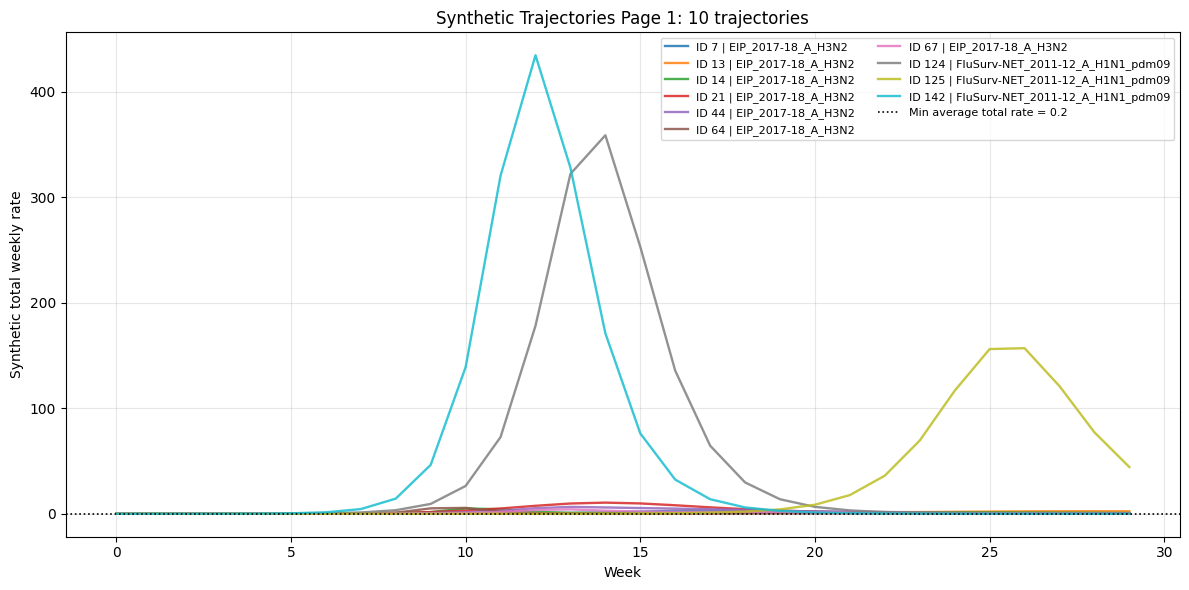

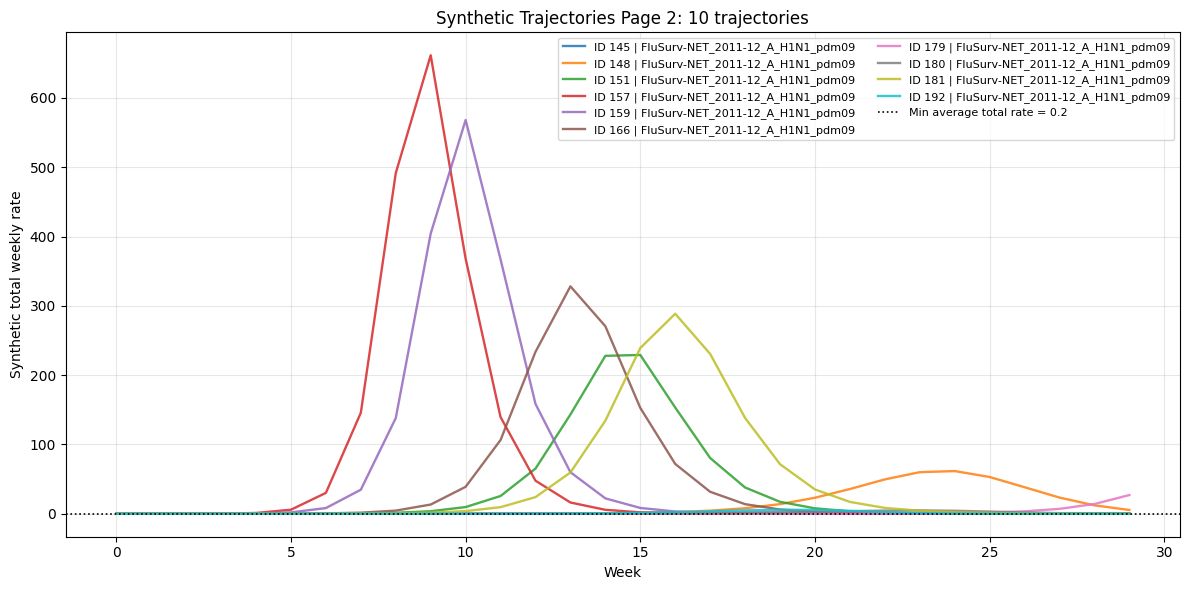

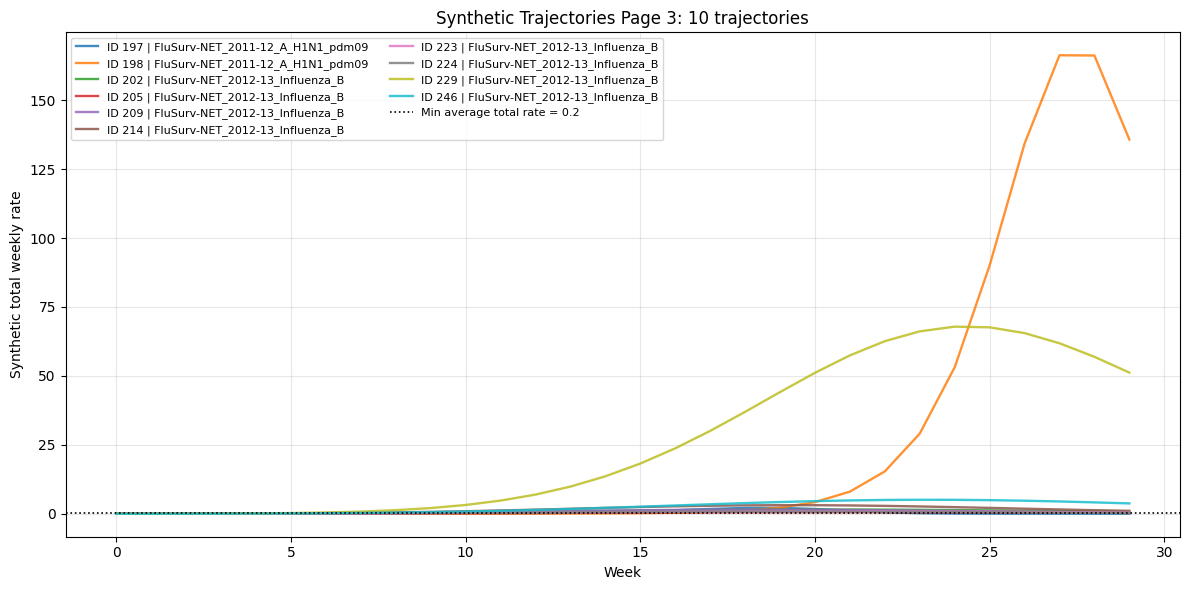

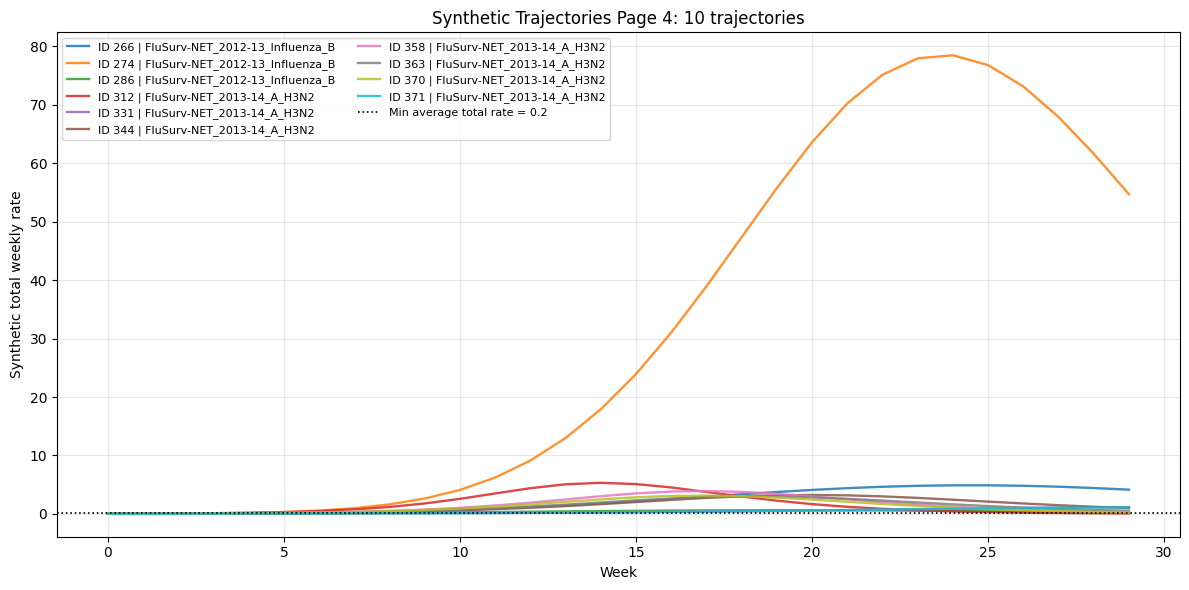

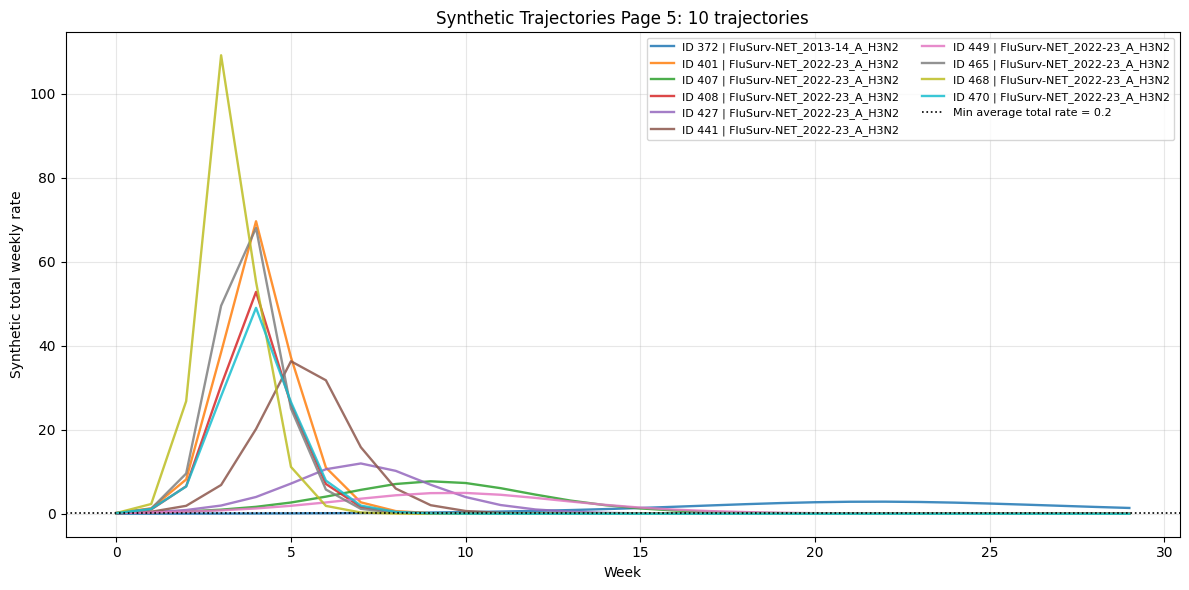

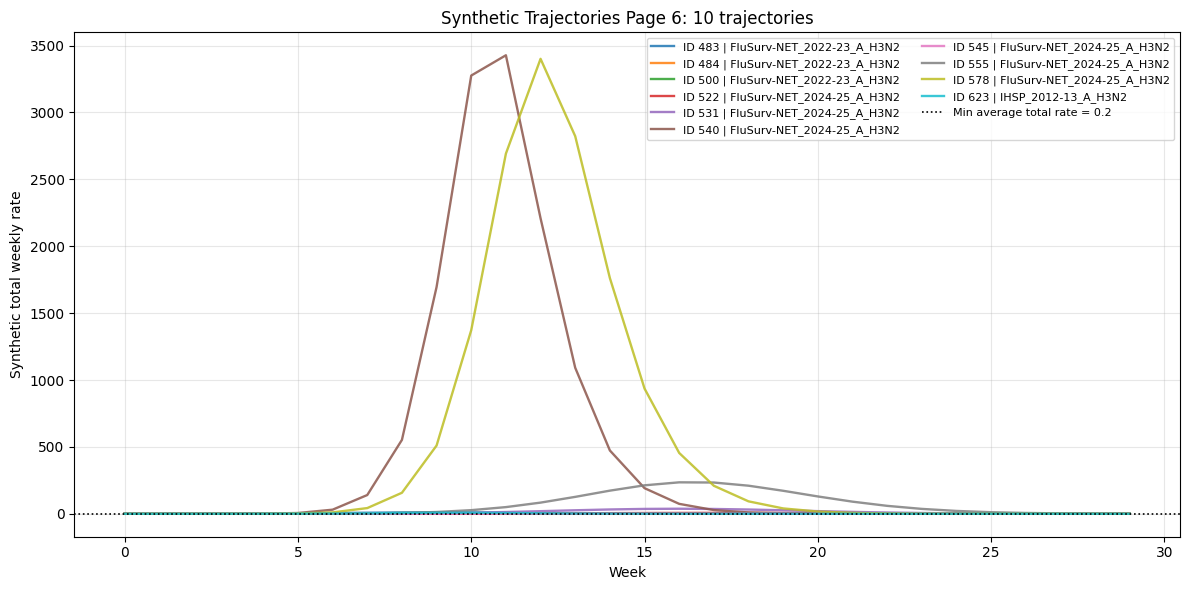

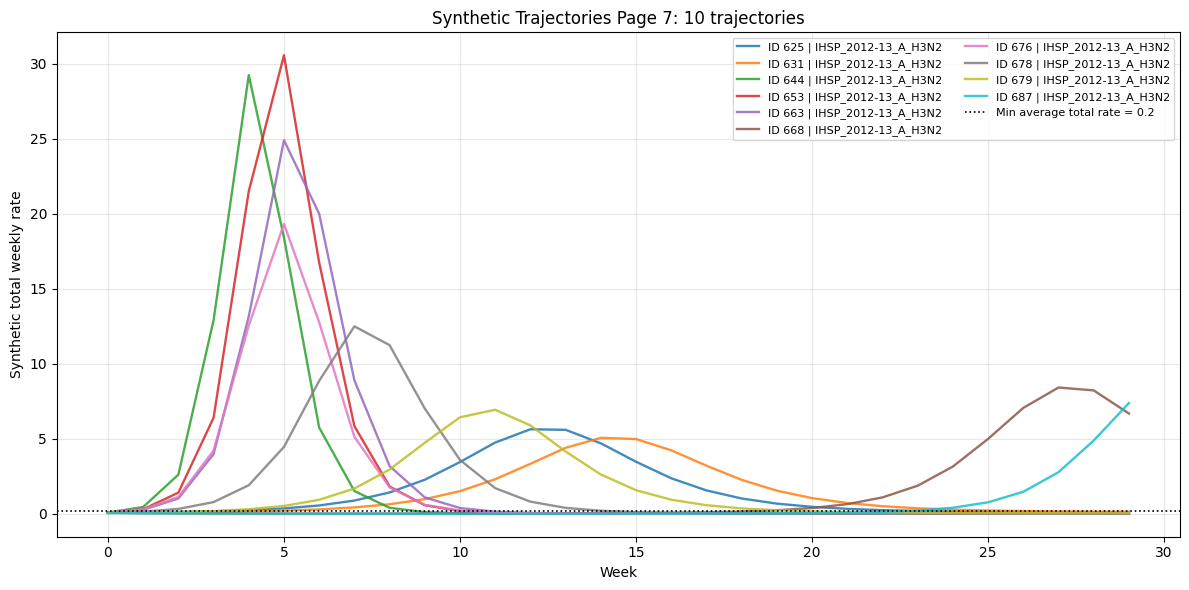

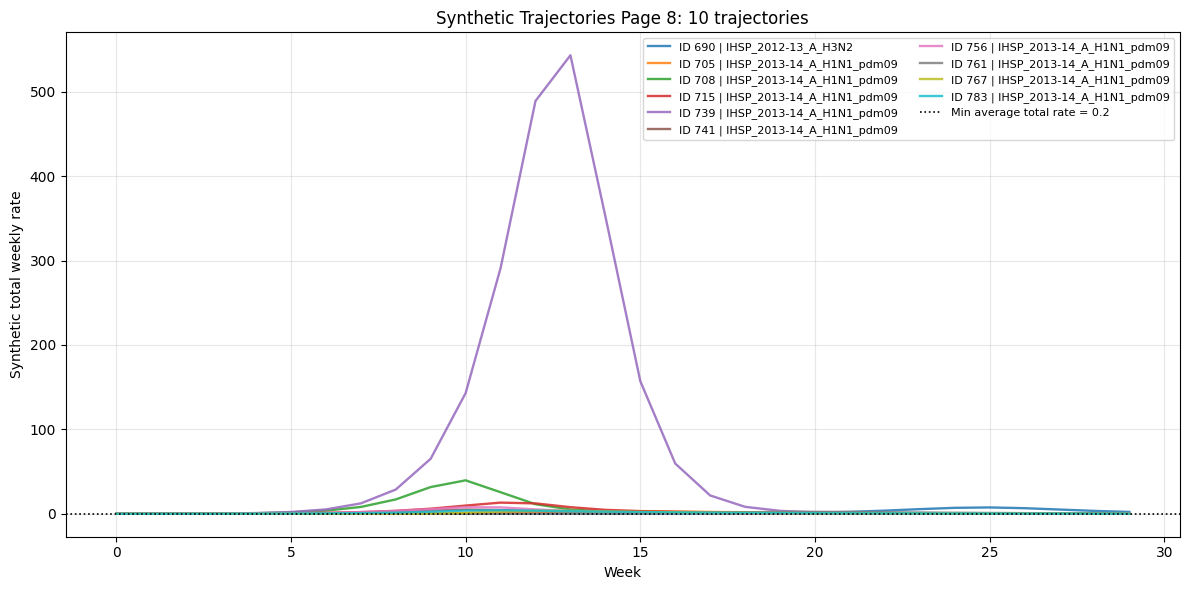

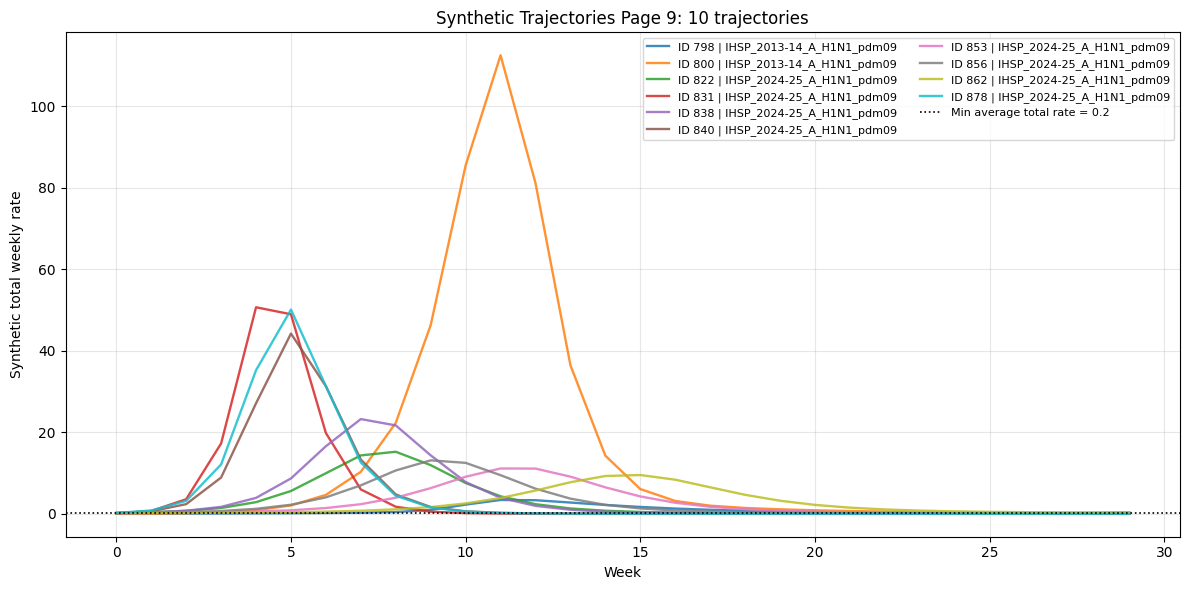

Saved synthetic trajectory display graphs:
Subset/virtual_examples.png
Subset/virtual_examples_page_02.png
Subset/virtual_examples_page_03.png
Subset/virtual_examples_page_04.png
Subset/virtual_examples_page_05.png
Subset/virtual_examples_page_06.png
Subset/virtual_examples_page_07.png
Subset/virtual_examples_page_08.png
Subset/virtual_examples_page_09.png


In [50]:
# ============================================================
# 4B. DISPLAY 10% OF SYNTHETIC TRAJECTORIES, 10 PER GRAPH
# ============================================================

if "virtual_df" not in globals() or virtual_df.empty:
    raise NameError("Run section 4 first so virtual_df exists.")

unique_virtual_ids = np.array(sorted(virtual_df["virtual_id"].unique()), dtype=int)
n_total_trajectories = len(unique_virtual_ids)
n_display_trajectories = max(
    1,
    int(np.ceil(SYNTHETIC_TRAJECTORY_DISPLAY_FRACTION * n_total_trajectories)),
)
n_display_trajectories = min(n_display_trajectories, n_total_trajectories)

rng = np.random.default_rng(SYNTHETIC_TRAJECTORY_DISPLAY_RANDOM_SEED)
display_virtual_ids = np.sort(
    rng.choice(unique_virtual_ids, size=n_display_trajectories, replace=False)
)

trajectories_per_graph = max(1, int(SYNTHETIC_TRAJECTORIES_PER_DISPLAY_GRAPH))
plot_output_paths = []

print(
    f"Displaying {n_display_trajectories} of {n_total_trajectories} synthetic trajectories "
    f"({100.0 * n_display_trajectories / n_total_trajectories:.1f}%), "
    f"with up to {trajectories_per_graph} trajectories per graph."
)

for page_index, start in enumerate(range(0, n_display_trajectories, trajectories_per_graph), start=1):
    page_ids = display_virtual_ids[start:start + trajectories_per_graph]
    page_df = virtual_df[virtual_df["virtual_id"].isin(page_ids)].copy()

    plt.figure(figsize=(12, 6))
    for virtual_id, traj in page_df.groupby("virtual_id"):
        traj = traj.sort_values("week")
        label = f"ID {virtual_id}"
        if "source_baseline" in traj.columns:
            label += f" | {traj['source_baseline'].iloc[0]}"
        plt.plot(
            traj["week"],
            traj["virtual_total_rate"],
            linewidth=1.7,
            alpha=0.85,
            label=label,
        )

    plt.axhline(
        MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE,
        color="black",
        linestyle=":",
        linewidth=1.2,
        label=f"Min average total rate = {MIN_SYNTHETIC_TRAJECTORY_MEAN_WEEKLY_RATE}",
    )
    plt.xlabel("Week")
    plt.ylabel("Synthetic total weekly rate")
    plt.title(
        f"Synthetic Trajectories Page {page_index}: "
        f"{len(page_ids)} trajectories"
    )
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    if page_index == 1:
        output_png = VIRTUAL_OUTPUT_PNG
    else:
        output_png = VIRTUAL_OUTPUT_PNG.with_name(
            f"{VIRTUAL_OUTPUT_PNG.stem}_page_{page_index:02d}{VIRTUAL_OUTPUT_PNG.suffix}"
        )
    plt.savefig(output_png, dpi=300)
    plot_output_paths.append(output_png)
    plt.show()

print("Saved synthetic trajectory display graphs:")
for output_png in plot_output_paths:
    print(output_png)


## 5. CNN and LSTM Forecasters Trained on Virtual Trajectories

Both models receive the first `GIVEN_VALUES` weeks of each synthetic trajectory as input and predict the remaining weeks. Per-sample z-score normalization is applied so the models learn trajectory *shape* independent of amplitude.

In [51]:
# ============================================================
# 5. OPTIONAL CNN AND LSTM FORECAST MODELS
# ============================================================
# Run this cell only after creating the virtual dataset.
# The default target is total weekly rate. You can change TARGET_COL
# to "virtual_strain1_rate" or "virtual_strain2_rate".

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, Flatten, BatchNormalization, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

TARGET_COL = "virtual_total_rate"
GIVEN_VALUES = 15
EPOCHS = 300
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
USE_EARLY_STOPPING = True



CNN_MODEL_PATH = ROOT / f"cnn_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}.keras"
CNN_METADATA_PATH = ROOT / f"cnn_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}_metadata.json"
CNN_PREDICTIONS_CSV = ROOT / f"cnn_paper_ode_predictions_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
CNN_PLOT_PATH = ROOT / f"cnn_paper_ode_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.png"

LSTM_MODEL_PATH = ROOT / f"lstm_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}.keras"
LSTM_METADATA_PATH = ROOT / f"lstm_paper_ode_{TARGET_COL}_given_{GIVEN_VALUES}_metadata.json"
MODEL_COMPARISON_CSV = ROOT / f"model_comparison_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
MODEL_COMPARISON_PNG = ROOT / f"model_comparison_{TARGET_COL}_given_{GIVEN_VALUES}.png"
MODEL_FORECAST_CSV = ROOT / f"cnn_lstm_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.csv"
MODEL_FORECAST_PNG = ROOT / f"cnn_lstm_forecast_{TARGET_COL}_given_{GIVEN_VALUES}.png"


def make_supervised_dataset_from_virtual(
    virtual_df: pd.DataFrame,
    target_col: str,
    given_values: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    wide = (
        virtual_df.pivot(index="virtual_id", columns="week", values=target_col)
        .sort_index(axis=1)
        .dropna()
    )

    values = wide.to_numpy(dtype=float)
    weeks_arr = wide.columns.to_numpy(dtype=int)

    if given_values >= values.shape[1]:
        raise ValueError("GIVEN_VALUES must be smaller than the total number of weeks.")

    X = values[:, :given_values]
    y = values[:, given_values:]

    return X, y, weeks_arr


X_raw, y_raw, cnn_weeks = make_supervised_dataset_from_virtual(
    virtual_df=virtual_df,
    target_col=TARGET_COL,
    given_values=GIVEN_VALUES,
)

# Per-trajectory normalization: each sample is scaled using only the mean/std
# of its own "given" window, instead of one global mean/std over the whole
# dataset. With a global scale, trajectories whose amplitude is above average
# get compressed toward zero in normalized space, and an MSE loss then learns
# to systematically underpredict their peaks. Per-sample scaling lets the
# network focus on the *shape* of each trajectory regardless of its absolute
# size.
X_scale_mean = X_raw.mean(axis=1, keepdims=True)
X_scale_std = X_raw.std(axis=1, keepdims=True)

# Floor each trajectory's scale at the dataset-wide std of the "given"
# window. With 73 perturbation baselines spanning very different peak
# timings, many trajectories have a near-flat (near-zero-variance) given
# window even though weeks GIVEN_VALUES: still contain a real peak.
# Dividing by that near-zero std blew normalized targets up to the
# hundreds, which is why loss/val_loss were stuck around 1e5 and diverging.
GLOBAL_SCALE_FLOOR = float(X_raw.std())
X_scale_std = np.maximum(X_scale_std, GLOBAL_SCALE_FLOOR)

X = (X_raw - X_scale_mean) / X_scale_std
y = (y_raw - X_scale_mean) / X_scale_std

X = X[..., None]

n_samples = X.shape[0]
rng = np.random.default_rng(123)
idx = rng.permutation(n_samples)

split = int(0.80 * n_samples)
train_idx = idx[:split]
val_idx = idx[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
X_scale_mean_val = X_scale_mean[val_idx]
X_scale_std_val = X_scale_std[val_idx]

forecast_horizon = y.shape[1]

def make_training_callbacks() -> list:
    callbacks = []
    if USE_EARLY_STOPPING:
        callbacks.append(
            EarlyStopping(
                monitor="val_loss",
                patience=30,
                restore_best_weights=True,
            )
        )
    return callbacks


def build_cnn_model() -> Sequential:
    model = Sequential([
        Input(shape=(GIVEN_VALUES, 1)),
        Conv1D(32, kernel_size=3, activation="relu", padding="causal"),
        BatchNormalization(),
        Dropout(0.15),

        Conv1D(64, kernel_size=3, activation="relu", padding="causal"),
        BatchNormalization(),
        Dropout(0.15),

        Flatten(),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(forecast_horizon),
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"],
    )
    return model


def build_lstm_model() -> Sequential:
    model = Sequential([
        Input(shape=(GIVEN_VALUES, 1)),
        LSTM(64, return_sequences=True),
        Dropout(0.15),
        LSTM(32),
        Dense(64, activation="relu"),
        Dropout(0.10),
        Dense(forecast_horizon),
    ])
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="mse",
        metrics=["mae"],
    )
    return model


def train_forecaster(
    model_name: str,
    build_model_fn,
    model_path: Path,
    metadata_path: Path,
) -> tuple[Sequential, object, dict]:
    tf.keras.utils.set_random_seed(123)
    model = build_model_fn()

    print(f"\nTraining {model_name} forecaster...")
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_training_callbacks(),
        verbose=1,
    )

    val_pred_scaled = model.predict(X_val, verbose=0)
    val_pred = val_pred_scaled * X_scale_std_val + X_scale_mean_val
    val_true = y_val * X_scale_std_val + X_scale_mean_val
    val_errors = val_pred - val_true
    best_val_loss = float(np.min(history.history["val_loss"]))
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    metrics = {
        "model": model_name,
        "target_col": TARGET_COL,
        "given_values": int(GIVEN_VALUES),
        "forecast_horizon": int(forecast_horizon),
        "epochs_run": int(len(history.history["loss"])),
        "best_epoch": best_epoch,
        "best_val_loss_scaled": best_val_loss,
        "final_val_loss_scaled": float(history.history["val_loss"][-1]),
        "val_rmse": float(np.sqrt(np.mean(val_errors ** 2))),
        "val_mae": float(np.mean(np.abs(val_errors))),
        "model_path": str(model_path),
        "metadata_path": str(metadata_path),
    }

    model.save(model_path)
    metadata = {
        "MODEL_NAME": model_name,
        "TARGET_COL": TARGET_COL,
        "GIVEN_VALUES": GIVEN_VALUES,
        "TOTAL_WEEKS": int(len(cnn_weeks)),
        "FORECAST_HORIZON": int(forecast_horizon),
        "weeks": cnn_weeks.tolist(),
        "normalization": "per_sample_zscore_of_given_window",
        "scale_floor": GLOBAL_SCALE_FLOOR,
        "validation_metrics": metrics,
    }

    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)

    return model, history, metrics


cnn_model, cnn_history, cnn_metrics = train_forecaster(
    "CNN",
    build_cnn_model,
    CNN_MODEL_PATH,
    CNN_METADATA_PATH,
)

lstm_model, lstm_history, lstm_metrics = train_forecaster(
    "LSTM",
    build_lstm_model,
    LSTM_MODEL_PATH,
    LSTM_METADATA_PATH,
)

model_comparison_df = pd.DataFrame([cnn_metrics, lstm_metrics]).sort_values("val_rmse")
model_comparison_df.to_csv(MODEL_COMPARISON_CSV, index=False)

plt.figure(figsize=(8, 5))
plt.bar(model_comparison_df["model"], model_comparison_df["val_rmse"])
plt.ylabel("Validation RMSE")
plt.title(f"CNN vs LSTM on {TARGET_COL}")
plt.grid(axis="y", alpha=0.35)
plt.tight_layout()
plt.savefig(MODEL_COMPARISON_PNG, dpi=300)
plt.show()

def observed_series_for_target(target_col: str) -> tuple[np.ndarray, np.ndarray, str]:
    """Return (weeks, mean_observed_values, label) from individual trajectory files."""
    if target_col == "virtual_total_rate":
        mat = _build_matrix(dataset_records, fit_weeks)
        return fit_weeks, np.nanmean(mat, axis=0), "Mean observed total"
    if target_col == "virtual_strain1_rate":
        a_recs = [r for r in dataset_records if r["virus"] in A_VIRUS_LABELS]
        mat = _build_matrix(a_recs, fit_weeks)
        return fit_weeks, np.nanmean(mat, axis=0), f"Mean observed {STRAIN1_NAME}"
    if target_col == "virtual_strain2_rate":
        b_recs = [r for r in dataset_records if r["virus"] in B_VIRUS_LABELS]
        mat = _build_matrix(b_recs, fit_weeks)
        return fit_weeks, np.nanmean(mat, axis=0), f"Mean observed {STRAIN2_NAME}"
    raise ValueError(f"No observed-series mapping for TARGET_COL={target_col!r}")


def forecast_observed_curve(model, observed_values: np.ndarray) -> np.ndarray:
    if len(observed_values) < len(cnn_weeks):
        raise ValueError(
            f"Observed curve has {len(observed_values)} values, but the model expects {len(cnn_weeks)} weeks."
        )

    observed_values = observed_values[:len(cnn_weeks)]
    given = observed_values[:GIVEN_VALUES]

    given_mean = float(given.mean())
    given_std = max(float(given.std()), GLOBAL_SCALE_FLOOR)

    X_user = ((given - given_mean) / given_std).reshape(1, GIVEN_VALUES, 1)
    pred_scaled = model.predict(X_user, verbose=0)[0]
    pred_future = pred_scaled * given_std + given_mean
    return np.concatenate([given, pred_future[: len(cnn_weeks) - GIVEN_VALUES]])


observed_weeks, observed_values, observed_label = observed_series_for_target(TARGET_COL)
observed_weeks = observed_weeks[:len(cnn_weeks)]
observed_values = observed_values[:len(cnn_weeks)]
cnn_forecast = forecast_observed_curve(cnn_model, observed_values)
lstm_forecast = forecast_observed_curve(lstm_model, observed_values)

forecast_df = pd.DataFrame({
    "week": observed_weeks,
    "observed_value": observed_values,
    "cnn_forecast": cnn_forecast,
    "lstm_forecast": lstm_forecast,
    "is_given_to_model": [True] * GIVEN_VALUES + [False] * (len(cnn_weeks) - GIVEN_VALUES),
})

for model_name in ["cnn", "lstm"]:
    forecast_df[f"{model_name}_error"] = forecast_df[f"{model_name}_forecast"] - forecast_df["observed_value"]
    forecast_df[f"{model_name}_absolute_error"] = np.abs(forecast_df[f"{model_name}_error"])
    forecast_df[f"{model_name}_squared_error"] = forecast_df[f"{model_name}_error"] ** 2

forecast_only = ~forecast_df["is_given_to_model"]
cnn_forecast_rmse = float(np.sqrt(forecast_df.loc[forecast_only, "cnn_squared_error"].mean()))
lstm_forecast_rmse = float(np.sqrt(forecast_df.loc[forecast_only, "lstm_squared_error"].mean()))
forecast_df["cnn_forecast_rmse"] = cnn_forecast_rmse
forecast_df["lstm_forecast_rmse"] = lstm_forecast_rmse
forecast_df.to_csv(MODEL_FORECAST_CSV, index=False)

plt.figure(figsize=(12, 7))
plt.plot(
    forecast_df["week"],
    forecast_df["observed_value"],
    marker="o",
    linewidth=2.5,
    label=observed_label,
)
plt.plot(
    forecast_df["week"],
    forecast_df["cnn_forecast"],
    marker="s",
    linestyle="--",
    linewidth=2.5,
    label=f"CNN forecast; RMSE={cnn_forecast_rmse:.4f}",
)
plt.plot(
    forecast_df["week"],
    forecast_df["lstm_forecast"],
    marker="^",
    linestyle="--",
    linewidth=2.5,
    label=f"LSTM forecast; RMSE={lstm_forecast_rmse:.4f}",
)
plt.axvline(
    x=int(forecast_df.loc[GIVEN_VALUES - 1, "week"]),
    linestyle=":",
    linewidth=2,
    label="Last given week",
)
plt.xlabel("Week")
plt.ylabel("Weekly rate")
plt.title(f"CNN vs LSTM Forecast on {TARGET_COL}")
plt.xticks(range(int(forecast_df["week"].min()), int(forecast_df["week"].max()) + 1))
plt.legend()
plt.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig(MODEL_FORECAST_PNG, dpi=300)
plt.show()

model = cnn_model
history = cnn_history
metadata = {
    "TARGET_COL": TARGET_COL,
    "GIVEN_VALUES": GIVEN_VALUES,
    "TOTAL_WEEKS": int(len(cnn_weeks)),
    "FORECAST_HORIZON": int(forecast_horizon),
    "weeks": cnn_weeks.tolist(),
    "normalization": "per_sample_zscore_of_given_window",
    "scale_floor": GLOBAL_SCALE_FLOOR,
}

print("Saved CNN model:")
print(CNN_MODEL_PATH)

print("\nSaved LSTM model:")
print(LSTM_MODEL_PATH)

print("\nSaved model comparison:")
print(MODEL_COMPARISON_CSV)
print(MODEL_COMPARISON_PNG)

display(model_comparison_df)



Training CNN forecaster...
Epoch 1/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.7508 - mae: 0.4537 - val_loss: 0.0362 - val_mae: 0.0627
Epoch 2/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0830 - mae: 0.1800 - val_loss: 0.0360 - val_mae: 0.0631
Epoch 3/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0456 - mae: 0.1085 - val_loss: 0.0353 - val_mae: 0.0649
Epoch 4/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0340 - mae: 0.0826 - val_loss: 0.0347 - val_mae: 0.0726
Epoch 5/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0308 - mae: 0.0791 - val_loss: 0.0343 - val_mae: 0.0739
Epoch 6/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0298 - mae: 0.0774 - val_loss: 0.0350 - val_mae: 0.0930
Epoch 7/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0292 - mae: 0.0722 - val_loss: 0.0311 - val_mae: 0.0944
Epoch 8/300
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0304 - mae: 0.0718 - val_loss: 0.0279 - val_mae: 0.0875
Epoch 9/300
45/45 ━━━━━━━━━━

KeyboardInterrupt: 

### 5C. Test Forecast Horizon on External CSV

CNN/LSTM forecast-horizon test results:


,csv_path,value_col,model,given_values,last_given_week,forecast_step,forecast_week,model_forecast_week,forecasted_value,actual_value,error,absolute_error,squared_error,rmse,overall_rmse
0,influenzaA2018.csv,influenzaA2018,CNN,15,14,1,15,15,1.352163,1.9,-0.547837,0.547837,0.300125,2.920512,2.920512
1,influenzaA2018.csv,influenzaA2018,CNN,15,14,2,16,16,1.251496,2.1,-0.848504,0.848504,0.719959,2.920512,2.920512
2,influenzaA2018.csv,influenzaA2018,CNN,15,14,3,17,17,1.076401,2.7,-1.623599,1.623599,2.636075,2.920512,2.920512
3,influenzaA2018.csv,influenzaA2018,CNN,15,14,4,18,18,0.850730,3.2,-2.349270,2.349270,5.519069,2.920512,2.920512
4,influenzaA2018.csv,influenzaA2018,CNN,15,14,5,19,19,0.751599,3.6,-2.848401,2.848401,8.113385,2.920512,2.920512
5,influenzaA2018.csv,influenzaA2018,CNN,15,14,6,20,20,0.572736,4.2,-3.627264,3.627264,13.157047,2.920512,2.920512
6,influenzaA2018.csv,influenzaA2018,CNN,15,14,7,21,21,0.418079,4.3,-3.881921,3.881921,15.069312,2.920512,2.920512
7,influenzaA2018.csv,influenzaA2018,CNN,15,14,8,22,22,0.327031,4.8,-4.472969,4.472969,20.007451,2.920512,2.920512
8,influenzaA2018.csv,influenzaA2018,CNN,15,14,9,23,23,0.236980,5.1,-4.863020,4.863020,23.648959,2.920512,2.920512
9,influenzaA2018.csv,influenzaA2018,CNN,15,14,10,24,24,0.128940,4.4,-4.271060,4.271060,18.241951,2.920512,2.920512


Overall forecast-horizon RMSE by model:
{'CNN': 2.920512221610563, 'LSTM': 2.88999047316476}


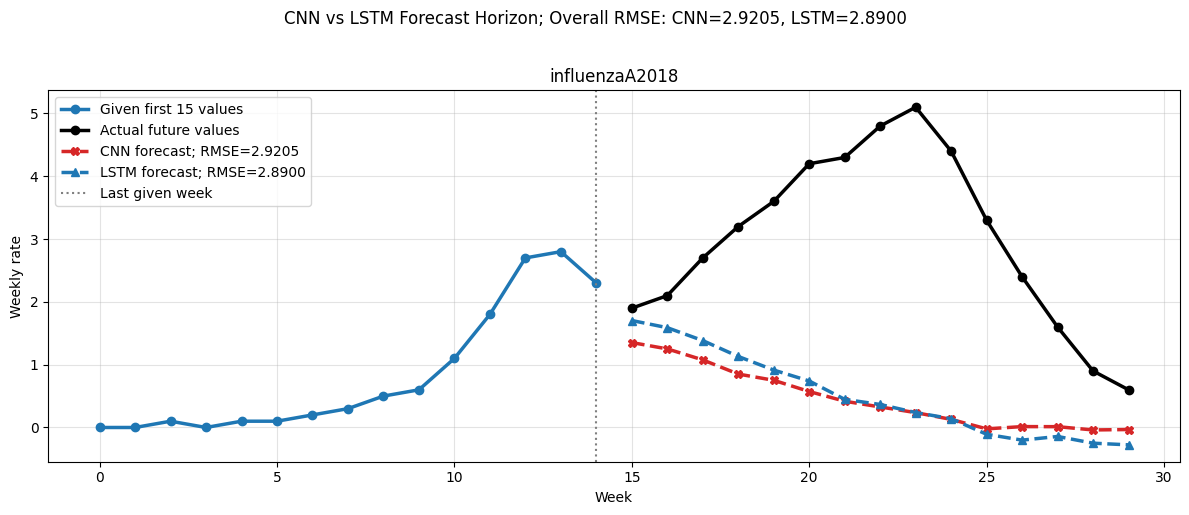


Saved forecast-horizon test CSV:
Subset/cnn_lstm_forecast_horizon_csv_test_results.csv

Saved CNN/LSTM forecast plot:
Subset/cnn_lstm_forecast_horizon_csv_test_prediction.png


In [ ]:
# ============================================================
# 5C. TEST CNN AND LSTM FORECAST HORIZON FROM CSV OR FOLDER
# ============================================================

from tensorflow.keras.models import load_model

# Use a single CSV, or set this to a folder containing CSV files.
# Examples:
#     TEST_INPUT_PATH = Path("influenzaA2018.csv")
#     TEST_INPUT_PATH = Path("influenza_A_B_overall_three_compartments/good_0_29")
# TEST_INPUT_PATH = Path("influenzaA2018.csv")
TEST_INPUT_PATH = Path("influenzaA2018.csv")
# TEST_INPUT_PATH = Path("SIR_Synthetic_Data.csv")

# Leave as None to auto-detect the first numeric non-week column.
# For influenzaA2018.csv, auto-detection will choose "influenzaA2018".
TEST_VALUE_COL = None

FORECAST_HORIZON_TEST_OUTPUT_CSV = ROOT / "cnn_lstm_forecast_horizon_csv_test_results.csv"
FORECAST_HORIZON_TEST_OUTPUT_PNG = ROOT / "cnn_lstm_forecast_horizon_csv_test_prediction.png"


def clean_csv_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(col).replace("\ufeff", "").strip() for col in df.columns]
    return df


def find_week_column(df: pd.DataFrame) -> str | None:
    for col in df.columns:
        if str(col).lower().replace(" ", "").replace("_", "") == "week":
            return col
    return None


def normalize_column_name(name: str) -> str:
    return str(name).lower().replace(" ", "").replace("_", "").replace("-", "")


def find_value_column(
    df: pd.DataFrame,
    requested_col: str | None,
    min_values: int,
    csv_path: Path,
) -> str:
    if requested_col is not None:
        if requested_col not in df.columns:
            raise ValueError(f"Column {requested_col!r} not found. Available columns: {list(df.columns)}")
        return requested_col

    week_col = find_week_column(df)
    preferred_names = [
        csv_path.stem,
        "WEEKLY RATE",
        "WEEKLY_RATE",
        "weekly_rate",
        "rate",
        "value",
    ]
    normalized_preferred = [normalize_column_name(name) for name in preferred_names]
    candidates = []
    for col in df.columns:
        if col == week_col:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        if values.notna().sum() >= min_values:
            candidates.append(col)

    if not candidates:
        raise ValueError(f"No numeric value column with at least {min_values} values. Columns: {list(df.columns)}")

    for preferred in normalized_preferred:
        for col in candidates:
            if normalize_column_name(col) == preferred:
                return col

    return candidates[0]


def collect_test_csv_paths(input_path: Path) -> list[Path]:
    input_path = Path(input_path)
    if input_path.is_dir():
        csv_paths = sorted(input_path.glob("*.csv"))
    else:
        csv_paths = [input_path]

    missing = [path for path in csv_paths if not path.exists()]
    if missing:
        raise FileNotFoundError(f"Missing test CSV path(s): {missing}")
    if not csv_paths:
        raise ValueError(f"No CSV files found in {input_path}")

    return csv_paths


def test_forecast_horizon_from_csv(
    csv_path: Path,
    models: dict[str, object],
    metadata: dict,
    value_col: str | None = None,
) -> tuple[list[dict], dict]:
    model_given_values = int(metadata["GIVEN_VALUES"])
    forecast_horizon = int(metadata["FORECAST_HORIZON"])
    cnn_weeks = np.array(metadata["weeks"], dtype=int)
    min_required_values = model_given_values + forecast_horizon

    df = clean_csv_columns(pd.read_csv(csv_path))
    week_col = find_week_column(df)
    chosen_value_col = find_value_column(df, value_col, min_required_values, csv_path)

    if week_col is not None:
        df[week_col] = pd.to_numeric(df[week_col], errors="coerce")
        df = df.dropna(subset=[week_col]).sort_values(week_col).reset_index(drop=True)

    value_series = pd.to_numeric(df[chosen_value_col], errors="coerce")
    valid_values = value_series.notna()

    if week_col is not None:
        observed_weeks = df.loc[valid_values, week_col].to_numpy(dtype=int)
    else:
        observed_weeks = np.arange(int(valid_values.sum()), dtype=int)

    observed_values = value_series.loc[valid_values].to_numpy(dtype=float)
    if len(observed_values) < min_required_values:
        raise ValueError(
            f"{csv_path} needs at least {min_required_values} numeric values, "
            f"but only has {len(observed_values)}."
        )

    given = observed_values[:model_given_values]
    actual_future = observed_values[model_given_values:min_required_values]
    forecast_weeks = observed_weeks[model_given_values:min_required_values]
    model_forecast_weeks = cnn_weeks[model_given_values:min_required_values]

    # Per-sample normalization: scale this CSV's "given" window using its own
    # mean/std, matching how the training data was normalized. This lets the
    # model forecast curves whose amplitude differs from the training set's
    # average without systematically underpredicting them.
    given_mean = float(given.mean())
    scale_floor = float(metadata.get("scale_floor", 1.0))
    given_std = max(float(given.std()), scale_floor)

    X_user = ((given - given_mean) / given_std).reshape(1, model_given_values, 1)

    result_rows = []
    pred_future_by_model = {}
    rmse_by_model = {}

    for model_name, model in models.items():
        pred_scaled = model.predict(X_user, verbose=0)[0]
        pred_future = (pred_scaled * given_std + given_mean)[:forecast_horizon]
        errors = pred_future - actual_future
        squared_errors = errors ** 2
        rmse = float(np.sqrt(np.mean(squared_errors)))

        pred_future_by_model[model_name] = pred_future
        rmse_by_model[model_name] = rmse

        for step, (week, model_week, forecasted, actual, error, squared_error) in enumerate(
            zip(forecast_weeks, model_forecast_weeks, pred_future, actual_future, errors, squared_errors),
            start=1,
        ):
            result_rows.append({
                "csv_path": str(csv_path),
                "value_col": chosen_value_col,
                "model": model_name,
                "given_values": model_given_values,
                "last_given_week": int(observed_weeks[model_given_values - 1]),
                "forecast_step": step,
                "forecast_week": int(week),
                "model_forecast_week": int(model_week),
                "forecasted_value": float(forecasted),
                "actual_value": float(actual),
                "error": float(error),
                "absolute_error": float(abs(error)),
                "squared_error": float(squared_error),
                "rmse": rmse,
            })

    plot_payload = {
        "label": csv_path.stem,
        "input_weeks": observed_weeks[:model_given_values],
        "given": given,
        "forecast_weeks": forecast_weeks,
        "actual_future": actual_future,
        "pred_future_by_model": pred_future_by_model,
        "rmse_by_model": rmse_by_model,
    }

    return result_rows, plot_payload


if not CNN_MODEL_PATH.exists():
    raise FileNotFoundError(f"CNN model not found: {CNN_MODEL_PATH}. Run section 5 first.")
if not CNN_METADATA_PATH.exists():
    raise FileNotFoundError(f"CNN metadata not found: {CNN_METADATA_PATH}. Run section 5 first.")
if not LSTM_MODEL_PATH.exists():
    raise FileNotFoundError(f"LSTM model not found: {LSTM_MODEL_PATH}. Run section 5 first.")
if not LSTM_METADATA_PATH.exists():
    raise FileNotFoundError(f"LSTM metadata not found: {LSTM_METADATA_PATH}. Run section 5 first.")

models = {
    "CNN": load_model(CNN_MODEL_PATH),
    "LSTM": load_model(LSTM_MODEL_PATH),
}

with open(CNN_METADATA_PATH, "r") as f:
    metadata = json.load(f)

results = []
plot_payloads = []
for csv_path in collect_test_csv_paths(TEST_INPUT_PATH):
    result_rows, plot_payload = test_forecast_horizon_from_csv(
        csv_path=csv_path,
        models=models,
        metadata=metadata,
        value_col=TEST_VALUE_COL,
    )
    results.extend(result_rows)
    plot_payloads.append(plot_payload)

forecast_horizon_results_df = pd.DataFrame(results)
overall_rmse_by_model = (
    forecast_horizon_results_df.groupby("model")["squared_error"]
    .mean()
    .pow(0.5)
    .to_dict()
)
forecast_horizon_results_df["overall_rmse"] = forecast_horizon_results_df["model"].map(overall_rmse_by_model)

forecast_horizon_results_df.to_csv(FORECAST_HORIZON_TEST_OUTPUT_CSV, index=False)

print("CNN/LSTM forecast-horizon test results:")
display(forecast_horizon_results_df)

print("Overall forecast-horizon RMSE by model:")
print(overall_rmse_by_model)

# ============================================================
# PLOT CNN AND LSTM FORECAST HORIZON
# ============================================================

n_plots = len(plot_payloads)
n_cols = 1 if n_plots == 1 else 2
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for ax, payload in zip(axes_flat, plot_payloads):
    ax.plot(
        payload["input_weeks"],
        payload["given"],
        marker="o",
        linewidth=2.5,
        label=f"Given first {metadata['GIVEN_VALUES']} values",
    )
    ax.plot(
        payload["forecast_weeks"],
        payload["actual_future"],
        color="black",
        marker="o",
        linewidth=2.5,
        label="Actual future values",
    )
    model_styles = {
        "CNN": {"color": "tab:red", "marker": "X"},
        "LSTM": {"color": "tab:blue", "marker": "^"},
    }
    for model_name, pred_future in payload["pred_future_by_model"].items():
        style = model_styles.get(model_name, {"color": None, "marker": "s"})
        ax.plot(
            payload["forecast_weeks"],
            pred_future,
            color=style["color"],
            marker=style["marker"],
            linestyle="--",
            linewidth=2.5,
            label=f"{model_name} forecast; RMSE={payload['rmse_by_model'][model_name]:.4f}",
        )
    ax.axvline(payload["input_weeks"][-1], color="gray", linestyle=":", linewidth=1.5, label="Last given week")
    ax.set_title(payload["label"])
    ax.set_xlabel("Week")
    ax.set_ylabel("Weekly rate")
    ax.legend()
    ax.grid(True, alpha=0.35)

for ax in axes_flat[n_plots:]:
    ax.axis("off")

rmse_summary = ", ".join(f"{name}={rmse:.4f}" for name, rmse in overall_rmse_by_model.items())
fig.suptitle(f"CNN vs LSTM Forecast Horizon; Overall RMSE: {rmse_summary}", y=1.02)
fig.tight_layout()
fig.savefig(FORECAST_HORIZON_TEST_OUTPUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved forecast-horizon test CSV:")
print(FORECAST_HORIZON_TEST_OUTPUT_CSV)

print("\nSaved CNN/LSTM forecast plot:")
print(FORECAST_HORIZON_TEST_OUTPUT_PNG)

